# ECE 232E course project — structured memory networks and RICR

This is the student starter for the complete 150-point project. It
follows the same execution order as the instructor run, but it does
**not** contain the reconciliation rule, network conclusions,
retrieval evaluator, reranking policy, RICR implementation,
ablation conclusions, answers, or report prose.

You will work with both supplied 100-question packages. Read
`PROJECT_HANDOUT.pdf` before editing this notebook. Every section
below corresponds to a numbered handout question, and every
explanation cell is part of the submission.

## How to run this notebook on a free Colab GPU

The neural stages are deliberately separated. Never keep two Qwen
models resident at once.

```text
CPU audit and indices
        ↓
Stage A: decomposer → save JSONL → unload model and clear CUDA
        ↓
Stage B: reranker   → save traces/rankings → unload and clear CUDA
        ↓
Stage C: answerer   → save predictions → unload and clear CUDA
```

During development, keep `QUESTION_LIMIT = 2`. Once your tests and
output schemas are correct, set it to `None`, enable exactly one
neural stage, and run all cells. Completed question IDs are read
from JSONL checkpoints, so reconnecting and running again resumes
rather than starts over. The supplied query vectors mean that you
must not load or regenerate the Qwen embedding model.

In [36]:
# Run controls. Change one neural stage at a time.
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False

# Use 2 while developing. Set to None for every required final run.
QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
DATASETS = ('2wiki', 'musique')

# Frozen default configuration from the project specification.
BEAM_WIDTH = 5
CANDIDATES_PER_HOP = 15
RETRIEVAL_POOL = 60
RRF_CONSTANT = 60.0
MULTI_PARENT_THRESHOLD = 0.3

In [2]:
from pathlib import Path
import gc, json, os, platform, shutil, subprocess, sys, time

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    REPO_ROOT = Path('/content/panini-course-project')
    if not (REPO_ROOT / 'manifest.json').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1',
            'https://github.com/YigitTurali/panini-course-project.git',
            str(REPO_ROOT),
        ], check=True)
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q', '-r',
        str(REPO_ROOT / 'requirements-colab.txt'),
    ], check=True)
    if MOUNT_DRIVE_IN_COLAB:
        from google.colab import drive
        drive.mount('/content/drive')
        WORK_ROOT = Path('/content/drive/MyDrive/panini-course-project-work')
    else:
        WORK_ROOT = Path('/content/panini-course-project-work')
else:
    here = Path.cwd().resolve()
    if (here / 'manifest.json').exists():
        REPO_ROOT = here
    else:
        source = here
        while source != source.parent and not (source / 'course_project').exists():
            source = source.parent
        if not (source / 'course_project').exists():
            raise FileNotFoundError('Run from the public repository or the gsw-memory checkout.')
        REPO_ROOT = source / 'course_project/release/panini_2wiki_100'
    WORK_ROOT = Path(os.environ.get('PANINI_STUDENT_WORK', here / 'panini-student-work'))

PACKAGE_ROOTS = {
    '2wiki': REPO_ROOT,
    'musique': REPO_ROOT / 'packages/panini_musique_100'
        if (REPO_ROOT / 'packages').exists()
        else REPO_ROOT.parent / 'panini_musique_100',
}
sys.path.insert(0, str(REPO_ROOT))
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Keep graded source edits in Drive/work storage, not only in the
# disposable /content clone. Edit this persistent file, then rerun
# the notebook so it is copied into the importable package.
STUDENT_CODE_ROOT = WORK_ROOT / 'student_code'
STUDENT_CODE_ROOT.mkdir(parents=True, exist_ok=True)
PERSISTENT_RICR = STUDENT_CODE_ROOT / 'ricr.py'
RUNTIME_RICR = REPO_ROOT / 'panini_course' / 'ricr.py'
if not PERSISTENT_RICR.exists():
    shutil.copy2(RUNTIME_RICR, PERSISTENT_RICR)
shutil.copy2(PERSISTENT_RICR, RUNTIME_RICR)

PERSISTENT_TESTS = STUDENT_CODE_ROOT / 'test_student_ricr.py'
if not PERSISTENT_TESTS.exists():
    PERSISTENT_TESTS.write_text(
        "import pytest\n\n"
        "@pytest.mark.skip(reason='Replace with your own reconciliation/RICR test')\n"
        "def test_student_failure_case():\n"
        "    pass\n",
        encoding='utf-8',
    )
RUNTIME_STUDENT_TESTS = REPO_ROOT / 'tests' / 'test_student_work.py'
shutil.copy2(PERSISTENT_TESTS, RUNTIME_STUDENT_TESTS)
print({
    'repo': str(REPO_ROOT), 'work': str(WORK_ROOT), 'colab': IN_COLAB,
    'edit_ricr_here': str(PERSISTENT_RICR),
    'edit_tests_here': str(PERSISTENT_TESTS),
})

Mounted at /content/drive
{'repo': '/content/panini-course-project', 'work': '/content/drive/MyDrive/panini-course-project-work', 'colab': True, 'edit_ricr_here': '/content/drive/MyDrive/panini-course-project-work/student_code/ricr.py', 'edit_tests_here': '/content/drive/MyDrive/panini-course-project-work/student_code/test_student_ricr.py'}


## Shared checkpoint and memory helpers

These helpers are infrastructure, not answers to a graded
algorithm. Each expensive stage appends one complete record at a
time. Do not keep results only in Python variables.

In [3]:
def read_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

def append_jsonl(path, row):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + '\n')

def completed_ids(path, *, configuration=None):
    rows = read_jsonl(path)
    if configuration is not None:
        rows = [row for row in rows if row.get('configuration') == configuration]
    return {str(row['question_id']) for row in rows}

def release_gpu(*objects):
    # Delete caller-owned model variables before calling this helper.
    for value in objects:
        del value
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass

def selected_questions(package):
    rows = package.questions('public') + package.questions('held_out')
    return rows if QUESTION_LIMIT is None else rows[:QUESTION_LIMIT]

def require_full_run():
    assert QUESTION_LIMIT is None, 'Set QUESTION_LIMIT = None before producing final files.'

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from IPython.display import display
from panini_course import CoursePackage

packages = {name: CoursePackage(path) for name, path in PACKAGE_ROOTS.items()}
for name, package in packages.items():
    print(name, package.manifest['counts'])

2wiki {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 765, 'gsws': 765, 'entities': 6805, 'qa_pairs': 8887}
musique {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 841, 'gsws': 841, 'entities': 8260, 'qa_pairs': 9991}


## Question 1 — understand and verify the two packages (6 points)

Audit stable identifiers and artifact alignment before doing any
retrieval. Equal row counts alone are not sufficient. Inspect one
public question, held-out question, entity, and QA record from each
dataset. Confirm that held-out rows expose no answer or gold
evidence fields.

In [5]:
import json, subprocess, sys
import pandas as pd

FORBIDDEN = {"answer", "answer_aliases", "supporting_facts", "evidences"}

def audit_package(package, dataset, root):
    public = package.questions("public")
    held_out = package.questions("held_out")
    entities = package.entities()
    qa_pairs = package.qa_pairs()
    decomp = package.decompositions()

    entity_uids = [x["entity_uid"] for x in entities]
    qa_uids = [x["qa_uid"] for x in qa_pairs]
    assert len(entity_uids) == len(set(entity_uids)), f"{dataset}: duplicate entity_uid"
    assert len(qa_uids) == len(set(qa_uids)), f"{dataset}: duplicate qa_uid"

    for q in held_out:
        leaked = FORBIDDEN & set(q)
        assert not leaked, f"{dataset}: held-out {q.get('question_id')} leaks {leaked}"

    return {
        "dataset": dataset,
        "total_questions": len(public) + len(held_out),
        "public_questions": len(public),
        "held_out_questions": len(held_out),
        "decomp_validation": len(decomp),
        "documents": package.manifest["counts"].get("documents", 0),
        "gsw_files": package.manifest["counts"].get("gsws", 0),
        "entities": len(entities),
        "qa_records": len(qa_pairs),
    }

# (a) Package counts + leakage/ID audit
q1_audit = pd.DataFrame([
    audit_package(package, dataset, PACKAGE_ROOTS[dataset])
    for dataset, package in packages.items()
])
display(q1_audit)

# (b) Schema examples
package = packages["2wiki"]
root = PACKAGE_ROOTS["2wiki"]

print("\n--- Schema examples (2wiki) ---")
print("\nQuestion:\n", package.questions("public")[0])
print("\nEntity:\n", package.entities()[0])
print("\nQA:\n", package.qa_pairs()[0])

# (c) Supplied tests
print("\n--- Pytest ---")
subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"],cwd=str(REPO_ROOT))

print("\nQ1 audit complete.")

,dataset,total_questions,public_questions,held_out_questions,decomp_validation,documents,gsw_files,entities,qa_records
0,2wiki,100,80,20,20,765,765,6805,8887
1,musique,100,80,20,80,841,841,8260,9991



--- Schema examples (2wiki) ---

Question:
 {'question_id': '5cbb015f087511ebbd67ac1f6bf848b6', 'type': 'bridge_comparison', 'question': 'Which film has the director died later, The Glass Wall or Where Does It Hurt??', 'context_document_ids': ['doc_876', 'doc_623', 'doc_877', 'doc_878', 'doc_626', 'doc_619', 'doc_879', 'doc_880', 'doc_881', 'doc_882'], 'answer': 'Where Does It Hurt?', 'answer_aliases': [], 'supporting_facts': [['The Glass Wall', 0], ['Where Does It Hurt?', 0], ['Maxwell Shane', 0], ['Rod Amateau', 0]], 'evidences': [['The Glass Wall', 'director', 'Maxwell Shane'], ['Where Does It Hurt?', 'director', 'Rod Amateau'], ['Maxwell Shane', 'date of death', 'October 25, 1983'], ['Rod Amateau', 'date of death', 'June 29, 2003']]}

Entity:
 {'entity_uid': 'doc_1::gsw_1_0.json::e1', 'document_id': 'doc_1', 'gsw_file': 'gsw_1_0.json', 'local_entity_id': 'e1', 'name': 'Theodred II', 'role_states': ['person: historical figure, medieval period', 'religious leader: Bishop of Elmham, 

### Your written response for Question 1

Stable-ID set equality matters because a result can have the correct structure while still containing the wrong questions. For example, a file might have 80 rows, valid JSON, and all the expected fields, but a ID could appear twice while another required question is missing. A basic shape check would not catch that because the number of rows and columns still looks correct. In the context of this data, a stable ID (such as 5cbb015f087511ebbd67ac1f6bf848b6) will clearly identify the specific question across decompositions, retrieval traces, generated answers, etc..

A plausable silent alignment bug could happen when results are joined by row order instead of question ID. Suppose two files contain the same 80 questions but were sorted differently. The rows would still line up structurally, yet an answer from one question could be attached to another question. The resulting metrics might even look reasonable (e,g. assert len). Using stable IDs for joins and validation avoids relying on ordering and makes sure that each result belongs to the correct question.


## Question 2 — build the GSW network and reconcile entities (12 points)

Keep three graph objects separate: the document-local occurrence
projection, the supplied exact-surface sensitivity baseline, and
your conservative reconciliation. Reconciliation is an analysis
mapping only; it must never rewrite the packaged IDs.

In [6]:
import collections, random, re, networkx as nx, pandas as pd
from panini_course.graph import build_entity_projection, build_native_gsw_graph, build_unreconciled_entity_projection

graph_sets = {}
print("--- Q2(a) Graph Construction ---")

for ds, package in packages.items():
    native = build_native_gsw_graph(package.gsw_paths())
    unrec = build_unreconciled_entity_projection(native)
    exact = build_entity_projection(native)
    graph_sets[ds] = {"native": native, "unreconciled": unrec, "exact_surface": exact}
    nt = collections.Counter(nx.get_node_attributes(native, "node_type").values())
    et = collections.Counter(nx.get_edge_attributes(native, "edge_type").values())
    print(f"[{ds}] Nodes={dict(nt)}, Edges={dict(et)}")
    print(f"  unreconciled={unrec.number_of_nodes()} | exact={exact.number_of_nodes()}")

print("\n--- Q2(b) Distinct Occurrence UIDs ---")
native = graph_sets["2wiki"]["native"]
unrec = graph_sets["2wiki"]["unreconciled"]

by_name = collections.defaultdict(list)
for n, d in native.nodes(data=True):
    if d.get("node_type") == "entity" and d.get("name"):
        by_name[d["name"].strip().casefold()].append(n)

for name, nodes in by_name.items():
    docs = {native.nodes[n].get("document_id") for n in nodes}
    if len(nodes) > 1 and len(docs) > 1:
        assert len(nodes) == len(set(nodes)) and all(n in unrec for n in nodes)
        print(f"'{name}' -> {len(nodes)} distinct cross-document UIDs")
        break

print("\n--- Q2(c) Conservative Reconciliation ---")

def _canon(s):
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", str(s))).strip().casefold()

GENERIC = {
    "award", "date", "date range", "ethnicity", "gender",
    "genre", "language", "nationality", "occupation", "position",
    "profession", "religion", "title", "year",
    "location", "person", "organization",
    "entity", "value"
}

def conservative_entity_mapping(native_graph):
    unrec = build_unreconciled_entity_projection(native_graph)
    by_name = collections.defaultdict(list)
    for n, d in native_graph.nodes(data=True):
        if d.get("node_type") == "entity" and d.get("name"):
            by_name[_canon(d["name"])].append(n)

    nbrs = {n: {_canon(native_graph.nodes[x].get("name", x)) for x in unrec.neighbors(n)} - {""} for n in unrec.nodes}
    roles = lambda n: {str(r.get("role", "")).strip().casefold() for r in native_graph.nodes[n].get("roles", []) or [] if r.get("role")}
    uf, decisions = nx.Graph(), []

    for canon, occs in by_name.items():
        uf.add_nodes_from(occs)
        for i, a in enumerate(occs):
            for b in occs[i + 1:]:
                da, db = native_graph.nodes[a], native_graph.nodes[b]
                if da.get("document_id") == db.get("document_id"):
                    continue
                ra, rb = roles(a), roles(b)
                shared_roles = (ra & rb) - GENERIC
                shared_nbrs = nbrs.get(a, set()) & nbrs.get(b, set())
                generic_name = re.fullmatch(r"[\d\s\-–.,]+", canon or "") is not None or len(canon) < 3 or (ra | rb).issubset(GENERIC)
                merged = not generic_name and bool(shared_roles) and bool(shared_nbrs)
                if merged:
                    uf.add_edge(a, b)
                decisions.append({"canonical_name": canon, "occurrence_a": a, "occurrence_b": b, "merged": merged, "shared_roles": sorted(shared_roles), "shared_nbrs": sorted(shared_nbrs)})

    mapping = {n: min(comp, key=str) for comp in nx.connected_components(uf) for n in comp}
    mapping.update({n: n for n in native_graph.nodes if n not in mapping})
    return mapping, decisions

def aggregate_projection(unrec, native_graph, mapping):
    G = nx.Graph()
    for n, d in unrec.nodes(data=True):
        gid = mapping.get(n, n)
        src = native_graph.nodes[n]
        name = src.get("name", d.get("name", d.get("canonical_surface", gid)))
        if gid not in G:
            G.add_node(gid, name=name, canonical_surface=name, occurrences=0, contributing_docs=set())
        G.nodes[gid]["occurrences"] += 1
        doc = d.get("document_id") or src.get("document_id")
        if doc:
            G.nodes[gid]["contributing_docs"].add(str(doc))

    for u, v, d in unrec.edges(data=True):
        a, b = mapping.get(u, u), mapping.get(v, v)
        if a == b:
            continue
        w = d.get("weight", 1)
        if G.has_edge(a, b):
            G[a][b]["weight"] += w
        else:
            G.add_edge(a, b, weight=w)

    for n in G:
        G.nodes[n]["contributing_docs"] = sorted(G.nodes[n]["contributing_docs"])
        G.nodes[n]["doc_count"] = len(G.nodes[n]["contributing_docs"])
    return G

print("\n--- Running Reconciliation ---")
for ds, gs in graph_sets.items():
    mapping, decisions = conservative_entity_mapping(gs["native"])
    conservative = aggregate_projection(gs["unreconciled"], gs["native"], mapping)
    gs.update({"conservative": conservative, "mapping": mapping, "decision_rows": decisions})
    print(f"[{ds}] conservative={conservative.number_of_nodes()} nodes, {conservative.number_of_edges()} edges | merges={sum(d['merged'] for d in decisions)}")

print("\n--- Q2(d) Fixed-Seed Merge Audit ---")
merged = [d for d in graph_sets["2wiki"]["decision_rows"] if d["merged"]]
random.seed(42)
audit_df = pd.DataFrame(random.sample(merged, min(16, len(merged))))
if not audit_df.empty:
    display(audit_df[["canonical_name", "occurrence_a", "occurrence_b", "shared_roles", "shared_nbrs"]])

print("\n--- Q2(e) Tests ---")

T = nx.MultiDiGraph()
T.add_node("a::v", node_type="verb_phrase", document_id="a")
T.add_node("a::e", node_type="entity", document_id="a", name="Paris", roles=[{"role": "location", "states": ["city"]}])
T.add_node("b::v", node_type="verb_phrase", document_id="b")
T.add_node("b::e", node_type="entity", document_id="b", name="Paris", roles=[{"role": "location", "states": ["city"]}])
T.add_node("c::e", node_type="entity", document_id="c", name="Paris", roles=[{"role": "person", "states": ["name"]}])
T.add_edge("a::v", "a::e", key="qa1", question_id="qa1")

assert T.has_edge("a::v", "a::e")
assert not T.has_edge("a::e", "a::v")
assert T["a::v"]["a::e"]["qa1"]["question_id"] == "qa1"

U = build_unreconciled_entity_projection(T)
assert {"a::e", "b::e", "c::e"} <= set(U.nodes)

mapping, decisions = conservative_entity_mapping(T)
assert mapping["a::e"] == "a::e"
assert mapping["b::e"] == "b::e"
assert mapping["c::e"] == "c::e"

assert any(d["occurrence_a"] == "a::e" and d["occurrence_b"] == "b::e" for d in decisions)

assert all(d["occurrence_a"] != "c::e" or not d["merged"] for d in decisions)

print("Q2 tests: PASS")

--- Q2(a) Graph Construction ---
[2wiki] Nodes={'entity': 6805, 'verb_phrase': 4246}, Edges={'qa': 9733}
  unreconciled=6805 | exact=5438
[musique] Nodes={'entity': 8260, 'verb_phrase': 4796}, Edges={'qa': 11123}
  unreconciled=8260 | exact=6736

--- Q2(b) Distinct Occurrence UIDs ---
'the film' -> 2 distinct cross-document UIDs

--- Q2(c) Conservative Reconciliation ---

--- Running Reconciliation ---
[2wiki] conservative=6769 nodes, 6425 edges | merges=42
[musique] conservative=8191 nodes, 8864 edges | merges=94

--- Q2(d) Fixed-Seed Merge Audit ---


,canonical_name,occurrence_a,occurrence_b,shared_roles,shared_nbrs
0,central queensland,doc_5982::gsw_5982_0.json::e2,doc_5983::gsw_5983_0.json::e2,[region],[australia]
1,australia,doc_5980::gsw_5980_0.json::e3,doc_5984::gsw_5984_0.json::e3,[country],[north queensland]
2,conquest of the planet of the apes,doc_1213::gsw_1213_0.json::e5,doc_1220::gsw_1220_0.json::e1,[film],[battle for the planet of the apes]
3,why did i get married,doc_5254::gsw_5254_0.json::e6,doc_5256::gsw_5256_0.json::e8,[film],[why did i get married too]
4,why did i get married,doc_194::gsw_194_0.json::e7,doc_5254::gsw_5254_0.json::e6,[film],[why did i get married too]
5,bangalore naatkal,doc_1785::gsw_1785_0.json::e14,doc_1786::gsw_1786_0.json::e1,[film],"[arya, bobby simha, rana daggubati, sri divya]"
6,australia,doc_5980::gsw_5980_0.json::e3,doc_5987::gsw_5987_0.json::e3,[country],[north queensland]
7,ricardo montalbán,doc_1216::gsw_1216_0.json::e8,doc_1220::gsw_1220_0.json::e8,[creative professional],[roddy mcdowall]
8,war for the planet of the apes,doc_1214::gsw_1214_0.json::e23,doc_1219::gsw_1219_0.json::e1,[film],[july 14 2017]
9,tomas milian,doc_3923::gsw_3923_0.json::e6,doc_3926::gsw_3926_0.json::e5,[creative professional],[sergio marazzi]



--- Q2(e) Tests ---
Q2 tests: PASS


### Your written response for Question 2
**Decision Rule**

My reconciliation rule is intentionally conservative. I first group entity occurrences by a normalized surface name, then compare occurrences from different documents. Two occurrences are merged only when they share a non-generic role (which are manually defined in a dictionary) and also share at least one normalized neighboring entity. Generic or weakly informative names and role-only matches are not enough to justify a merge. Otherwise, the occurrences remain separate.

**False Merge and Missed Alias examples**

The two Mountain View occurrences `doc_5312::gsw_5312_0.json::e3` and `doc_5315::gsw_5315_0.json::e2` were merged because both were classified as cities and shared Mountain View Airport as a neighbor. However, `doc_5312::gsw_5312_0.json::e3` is described only as an urban area (which could refer to Mountain View, CA), while `doc_5315::gsw_5315_0.json::e2` is specifically associated with Howell County, Missouri, United States. This well implies that the merge incorrectly combined two separate entities.

A missed alias shows the opposite effect. `doc_629::gsw_629_0.json::e1` is Bruce Leung Siu-lung, a person and actor, while `doc_629::gsw_629_0.json::e5` is Bruce Leung, explicitly marked as an alias and stage name. Because their surface forms differ, the reconciliation procedure never compares them, so they remain separate vertices with split edges even though the graph indicates that they refer to the same entity. Reconciliation changes nodes, connectivity, and reachable paths, making it a mathematical change to the graph rather than simple label cleanup.




## Question 3 — analyze the structured-memory network (12 points)

Perform the full sensitivity analysis on 2Wiki. For MuSiQue,
produce the compact transfer table required by the handout. A
centrality ranking is not self-interpreting: inspect the semantic
role, contributing documents, and reconciliation decision for each
apparent hub.

--- Q3(a) 2Wiki Sensitivity ---


,nodes,edges,components,giant_size,giant_frac,isolates,min_comp,median_comp,mean_comp,max_comp,avg_deg,max_deg,clustering,assortativity,dataset,projection,top5_nodes
0,11051,9225,1986,54,0.004886,1052,1,1.0,5.564451,54,1.669532,24,0.000000,-0.101613,2wiki,native,NaN
1,6805,6436,1984,38,0.005584,1102,1,1.0,3.429940,38,1.891550,33,0.035659,-0.144423,2wiki,unreconciled,NaN
2,5438,6333,1012,3088,0.567856,758,1,1.0,5.373518,3088,2.329165,79,0.032218,0.009159,2wiki,exact_surface,NaN
3,6769,6425,1959,65,0.009603,1102,1,1.0,3.455334,65,1.898360,33,0.035423,-0.145528,2wiki,conservative,NaN



--- Q3(a) MuSiQue Transfer ---


,projection,components,giant_frac,isolates,avg_deg,max_deg,top5_nodes
5,unreconciled,2638,0.004116,1308,2.162470,33,LeBron James (33.0); Dwyane Wade (29.0); Build...
6,exact_surface,1425,0.490202,835,2.606888,71,United States (82.0); Australia (45.0); Americ...
7,conservative,2602,0.007447,1308,2.164327,33,LeBron James (33.0); Ted Mosby (How I Met Your...



--- Q3(a) Connectivity Changes ---


,projection,Δ components,Δ giant_size,Δ giant_frac,Δ isolates,Δ median_comp,Δ mean_comp,Δ max_comp
2,exact_surface,-972,3050,0.562272,-344,0.0,1.943578,3050
3,conservative,-25,27,0.004018,0,0.0,0.025395,27



--- Q3(a) Degree Changes ---


,projection,Δ avg_deg,Δ max_deg
2,exact_surface,0.437615,46
3,conservative,0.006810,0


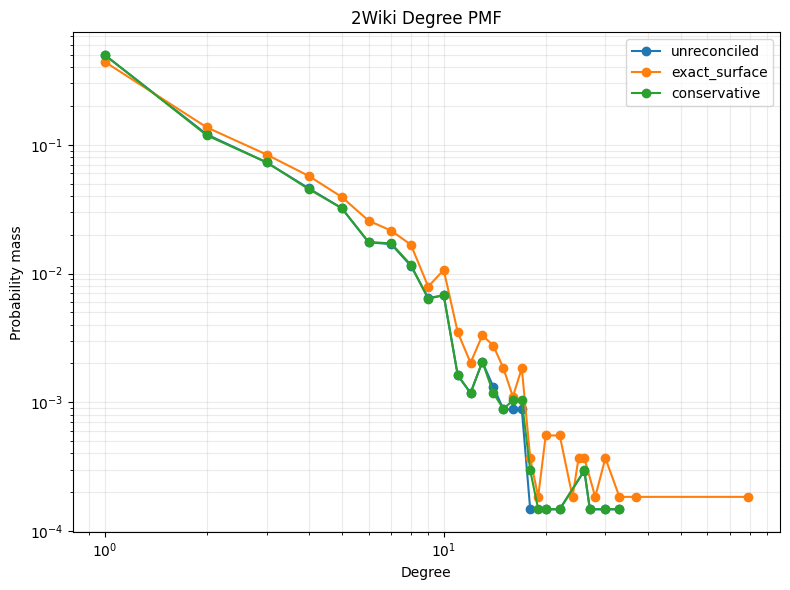

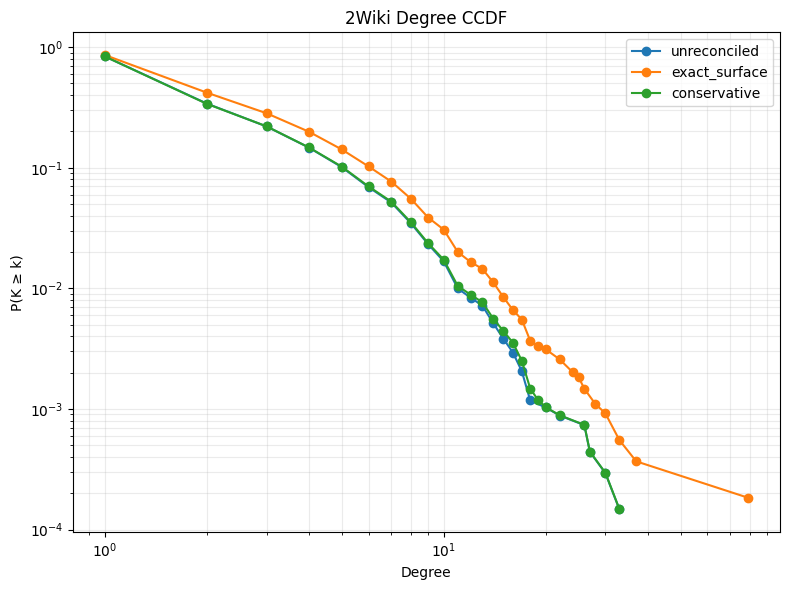

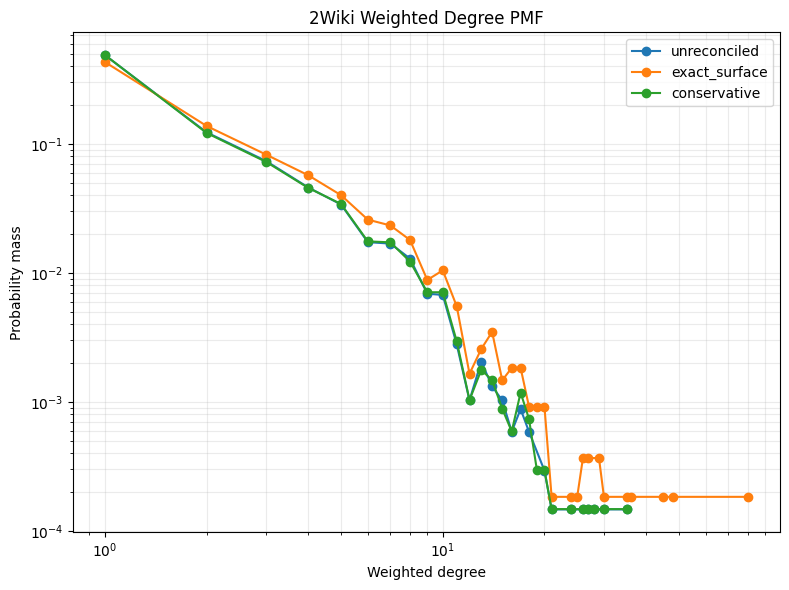

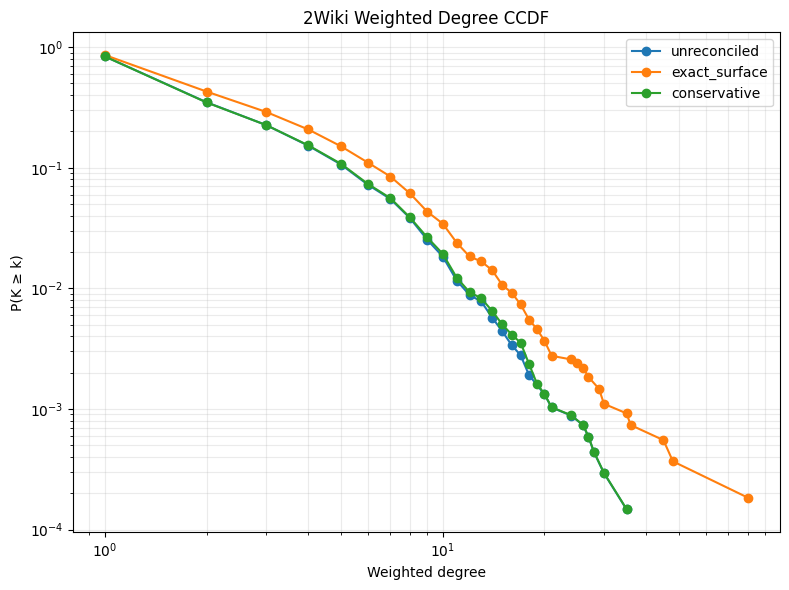


--- Q3(c) 2Wiki Centrality Audit ---

=== UNRECONCILED ===
Weighted Degree: David Ryan Adams (35.000), Jesús Rosas Marcano (30.000), Michael Curtiz (28.000), Walter George Mitchell (27.000), Sir Sidney Poitier (26.000), Hans Barthold Andresen Butenschøn (24.000), William Barnard (21.000), Amy (20.000), Jacques Pierre Paul Raverat (20.000), Howard Winchester Hawks (18.000)
PageRank: Hans Barthold Andresen Butenschøn (0.002), Walter George Mitchell (0.002), Michael Curtiz (0.001), Jesús Rosas Marcano (0.001), Emmanuel Amand de Mendieta (0.001), Zhao Jiong (0.001), Will Inman (0.001), Sher Shah Suri (0.001), Fannā (Panāh) Khusraw (0.001), Ruslana Stepanivna Lyzhychko (0.001)
Betweenness: Michael Curtiz (0.000), Hans Barthold Andresen Butenschøn (0.000), David Ryan Adams (0.000), Jesús Rosas Marcano (0.000), William Barnard (0.000), Sir Sidney Poitier (0.000), Manuel Romeo (0.000), Walter George Mitchell (0.000), Ralph L. Thomas (0.000), Vatroslav Mimica (0.000)

=== EXACT_SURFACE ===
Wei

,projection,clustering,assortativity
1,unreconciled,0.035659,-0.144423
2,exact_surface,0.032218,0.009159
3,conservative,0.035423,-0.145528



--- Q3(d) Gold Multi-hop Path ---


/tmp/ipykernel_684/173860226.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis("off"); plt.tight_layout()


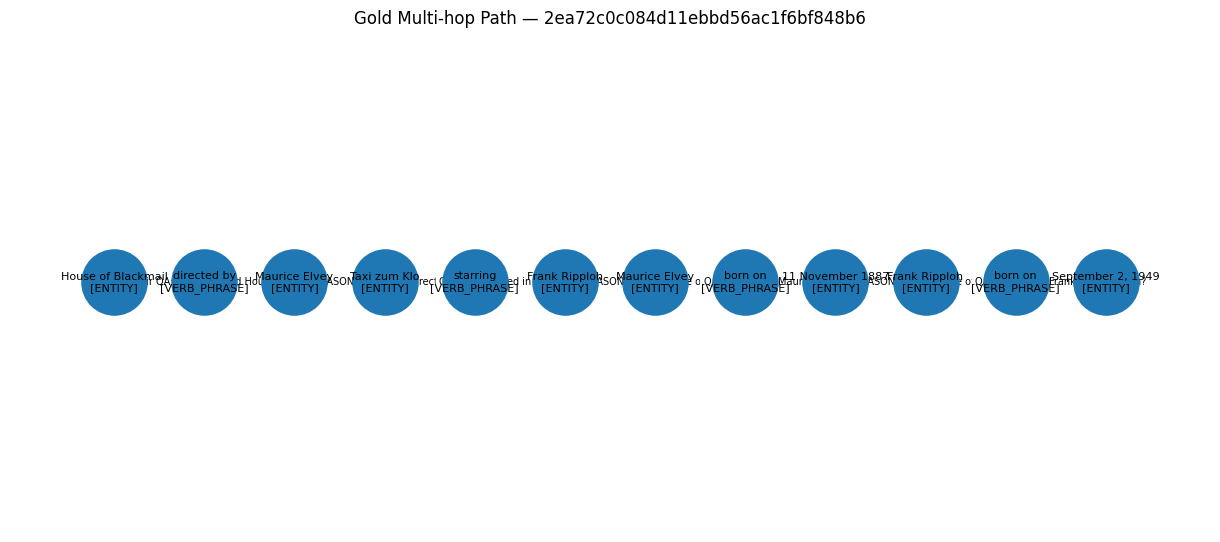

In [7]:
import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt, collections, re

# Define FIGURE_ROOT and create the directory
FIGURE_ROOT = WORK_ROOT / "figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

P=["unreconciled","exact_surface","conservative"]
C=["native"]+P

def ug(g):
    if isinstance(g,(nx.MultiGraph,nx.MultiDiGraph)):
        G=nx.Graph(); G.add_nodes_from(g.nodes(data=True))
        for u,v,d in g.edges(data=True):
            G.add_edge(u,v,weight=G.get_edge_data(u,v,{}).get("weight",0)+d.get("weight",1))
        return G
    return g.to_undirected() if g.is_directed() else g.copy()

def stats(g):
    G=ug(g); sizes=[len(c) for c in (nx.weakly_connected_components(g) if g.is_directed() else nx.connected_components(G))]
    deg=dict(G.degree()); n=G.number_of_nodes()
    return dict(nodes=n,edges=G.number_of_edges(),components=len(sizes),
        giant_size=max(sizes) if sizes else 0,giant_frac=max(sizes)/n if n else 0,
        isolates=nx.number_of_isolates(G),min_comp=min(sizes) if sizes else 0,
        median_comp=np.median(sizes) if sizes else 0,mean_comp=np.mean(sizes) if sizes else 0,
        max_comp=max(sizes) if sizes else 0,avg_deg=np.mean(list(deg.values())) if deg else 0,
        max_deg=max(deg.values()) if deg else 0,clustering=nx.average_clustering(G,weight="weight"),
        assortativity=nx.degree_assortativity_coefficient(G))

rows=[]
for ds,gs in graph_sets.items():
    for name in C:
        s=stats(gs[name]); s.update(dataset=ds,projection=name)
        if ds=="musique" and name!="native":
            top=sorted(gs[name].degree(weight="weight"),key=lambda x:-x[1])[:5]
            s["top5_nodes"]="; ".join(f"{gs[name].nodes[n].get('name',gs[name].nodes[n].get('canonical_surface',n))} ({w:.1f})" for n,w in top)
        rows.append(s)

q3_stats_df=pd.DataFrame(rows)
print("--- Q3(a) 2Wiki Sensitivity ---")
display(q3_stats_df[q3_stats_df.dataset=="2wiki"])

print("\n--- Q3(a) MuSiQue Transfer ---")
display(q3_stats_df[(q3_stats_df.dataset=="musique")&(q3_stats_df.projection!="native")]
        [["projection","components","giant_frac","isolates","avg_deg","max_deg","top5_nodes"]])

base=q3_stats_df[(q3_stats_df.dataset=="2wiki")&(q3_stats_df.projection=="unreconciled")].iloc[0]
q3_sensitivity=q3_stats_df[(q3_stats_df.dataset=="2wiki")&q3_stats_df.projection.isin(["exact_surface","conservative"])].copy()
for x in ["components","giant_size","giant_frac","isolates","median_comp","mean_comp","max_comp","avg_deg","max_deg"]:
    q3_sensitivity[f"Δ {x}"]=q3_sensitivity[x]-base[x]

print("\n--- Q3(a) Connectivity Changes ---")
display(q3_sensitivity[["projection","Δ components","Δ giant_size","Δ giant_frac","Δ isolates","Δ median_comp","Δ mean_comp","Δ max_comp"]])

print("\n--- Q3(a) Degree Changes ---")
display(q3_sensitivity[["projection","Δ avg_deg","Δ max_deg"]])

# (b) Degree / weighted-degree PMF + CCDF
def dist(g,weighted=False):
    G=ug(g); d=np.array([x for _,x in G.degree(weight="weight" if weighted else None)],float)
    if not len(d): return [],[],[]
    c=collections.Counter(d); x=np.array(sorted(c),float)
    return x,np.array([c[v]/len(d) for v in x]),np.array([np.mean(d>=v) for v in x])

for weighted,s in [(False,"degree"),(True,"weighted_degree")]:
    for kind in ["pmf","ccdf"]:
        plt.figure(figsize=(8,6))
        for name in P:
            x,p,c=dist(graph_sets["2wiki"][name],weighted); y=p if kind=="pmf" else c; m=(x>0)&(y>0)
            plt.loglog(x[m],y[m],"o-",label=name)
        plt.xlabel("Weighted degree" if weighted else "Degree")
        plt.ylabel("Probability mass" if kind=="pmf" else "P(K ≥ k)")
        plt.title(f"2Wiki {s.replace('_',' ').title()} {kind.upper()}")
        plt.legend(); plt.grid(True,which="both",alpha=.25); plt.tight_layout()
        plt.savefig(FIGURE_ROOT/f"2wiki_{s}_{kind}.png",dpi=200); plt.show(); plt.close()

# (c) Centrality audit
print("\n--- Q3(c) 2Wiki Centrality Audit ---")
q3_centrality={}
for name in P:
    G=ug(graph_sets["2wiki"][name])
    scores={
        "Weighted Degree":dict(G.degree(weight="weight")),
        "PageRank":nx.pagerank(G,weight="weight"),
        "Betweenness":nx.betweenness_centrality(G,k=min(1000,G.number_of_nodes()),seed=42)}
    q3_centrality[name]=scores
    print(f"\n=== {name.upper()} ===")
    for label,vals in scores.items():
        top=sorted(vals.items(),key=lambda x:-x[1])[:10]
        print(label+": "+", ".join(f"{G.nodes[n].get('name',G.nodes[n].get('canonical_surface',n))} ({v:.3f})" for n,v in top))

# (d) Clustering + assortativity
print("\n--- Q3(d) Clustering & Assortativity ---")
display(q3_stats_df[(q3_stats_df.dataset=="2wiki")&(q3_stats_df.projection!="native")]
        [["projection","clustering","assortativity"]])

# (d) Complete gold multi-hop path
print("\n--- Q3(d) Gold Multi-hop Path ---")
native=graph_sets["2wiki"]["native"]

def canon(s): return re.sub(r"\s+"," ",re.sub(r"[^\w\s]"," ",str(s))).strip().casefold()
def find_entity(s): return [n for n,d in native.nodes(data=True) if d.get("node_type")=="entity" and canon(d.get("name",n))==canon(s)]
def find_vp(a,b):
    ns=set(native.predecessors(a))|set(native.successors(a))
    no=set(native.predecessors(b))|set(native.successors(b))
    return next((n for n in ns&no if str(native.nodes[n].get("node_type"," ")).lower()=="verb_phrase"),None)
def edge_label(vp,o):
    d=native.get_edge_data(vp,o) or native.get_edge_data(o,vp) or {}
    if isinstance(d,dict) and d and not ("question" in d or "question_id" in d):
        d=next(iter(d.values()))
    return d.get("question") or d.get("question_id") or "N/A"

gold_q=resolved=None
for q in packages["2wiki"].questions("public"):
    hops=[]
    for sub,rel,obj in q.get("evidences",[]):
        hit=next(((a,find_vp(a,b),b,rel) for a in find_entity(sub) for b in find_entity(obj) if find_vp(a,b)),None)
        if not hit: hops=[]; break
        hops.append(hit)
    if hops and len(hops)==len(q.get("evidences",[])): gold_q,resolved=q,hops; break

if gold_q:
    H=nx.DiGraph()
    for i,(s,vp,o,rel) in enumerate(resolved,1):
        H.add_edge(f"{i}s",f"{i}v",label=rel)
        H.add_edge(f"{i}v",f"{i}o",label=f"QA: {edge_label(vp,o)}")
        H.nodes[f"{i}s"]["label"]=f"{native.nodes[s].get('name',s)}\n[ENTITY]"
        H.nodes[f"{i}v"]["label"]=f"{native.nodes[vp].get('phrase',vp)}\n[VERB_PHRASE]"
        H.nodes[f"{i}o"]["label"]=f"{native.nodes[o].get('name',o)}\n[ENTITY]"
        if i<len(resolved): H.add_edge(f"{i}o",f"{i+1}s",label="GOLD REASONING LINK")

    pos={n:(i,0) for i,n in enumerate(H.nodes())}
    plt.figure(figsize=(12,5))
    nx.draw(H,pos,labels=nx.get_node_attributes(H,"label"),node_size=2200,arrows=True,font_size=8)
    nx.draw_networkx_edge_labels(H,pos,edge_labels=nx.get_edge_attributes(H,"label"),font_size=7)
    plt.title(f"Gold Multi-hop Path — {gold_q['question_id']}")
    plt.axis("off"); plt.tight_layout()
    plt.savefig(FIGURE_ROOT/"2wiki_gold_multihop_path.png",dpi=200); plt.show()
else:
    print("Could not resolve a complete gold path.")

### Your written response for Question 3

**Cross-dataset interpretation**

The 2Wiki and MuSiQue graphs show that reconciliation can have a much larger structural effect than the local GSW structure itself. From the data, the 2wiki unreconciled graph has 6,805 nodes, 1,984 components, and a giant-component fraction of only 0.0056. Conservative reconciliation changes this only slightly as the graph has 6,769 nodes and 1,959 components, while the giant-component fraction rises only to 0.0096. Exact-surface reconciliation behaves differently, reducing the component count to 1,012 and increasing the giant component to 3,088 nodes, (~57% of the graph). Its average degree rises to 2.329 and its maximum degree increases from 33 to 79.

 The same pattern appears in MuSiQue: exact-surface reconciliation raises the giant-component fraction to 49.0%, while the conservative projection remains at only 0.0074. Evidently, much of this dramatic connectivity introduced by exact-surface matching can be traced to cross-document identity merging rather than structure already present inside individual GSWs.

This difference also appears in clustering and assortativity. Conservative 2Wiki has clustering 0.0354 and assortativity -0.1455, nearly identical to the unreconciled values of 0.0357 and -0.1444. Exact-surface reconciliation changes these to 0.0322 and 0.0092. The near stability of these conservative statistics supports the view that it adds relatively few structural bridges, whereas exact-surface matching substantially affects the graph.

**Hub explanation**

The hub results show why a high degree does not necessarily imply a hub is semantically real. In the unreconciled 2Wiki graph, the highest weighted-degree nodes are David Ryan Adams (35), Jesús Rosas Marcano (30), and Michael Curtiz (28). These hubs are supported by relationships within the original GSW structure, and they remain almost unchanged after conservative reconciliation. The same entities still dominate the weighted-degree rankings, with 'War for the Planet of the Apes' appearing at 19. This stability suggests that their prominence is primarily a property of the local graph structure rather than an artifact introduced by reconciliation.

Exact-surface reconciliation, however, produces a very different pattern. Generic terms become far stronger hubs. American reaches a weighted degree of 80, actor reaches 48, film director reaches 45, and screenwriter reaches 36. These nodes become highly connected because occurrences with the same surface name are collapsed into shared vertices, linking relationships that were previously distributed across separate nodes. The betweenness results reinforce this distinction. American has a betweenness of 0.184, whereas the highest values in the unreconciled and conservative graphs are effectively zero. Evidently, American appears prominent mainly because of aggressive reconciliation, not because it is a genuinely central semantic entity.

## Stage A — Question 4: decomposition and dependency graphs (14 points)

This is the first neural stage. It loads only the 4B decomposer,
writes the raw response before parsing, and unloads the model when
finished. Implement validation before starting the 200-question
run. Invalid JSON, forward references, missing nodes, and cycles
must remain visible in the cache rather than being silently fixed.

In [8]:
import re, networkx as nx

def validate_decomposition(plan):
    if not isinstance(plan,list) or not plan: return {"valid":False,"errors":["Invalid plan"],"edges":[]}
    errors,edges=[],[]
    for i,step in enumerate(plan,1):
        if not isinstance(step,dict) or not {"question","requires_retrieval"}<=step.keys():
            errors.append(f"Q{i}: malformed step"); continue
        text=str(step["question"]).strip()
        if step["requires_retrieval"] and not text: errors.append(f"Q{i}: empty retrieval question")
        for ref in map(int,re.findall(r"<ENTITY_Q(\d+)>",text)):
            if ref>=i or ref<1: errors.append(f"Q{i}: invalid reference Q{ref}")
            else: edges.append((ref,i))
    dag=nx.DiGraph(); dag.add_edges_from(edges)
    if not nx.is_directed_acyclic_graph(dag): errors.append("dependency cycle")
    return {"valid":not errors,"errors":errors,"edges":edges}

def retrieval_components(plan):
    val=validate_decomposition(plan)
    retrieval={i for i,step in enumerate(plan,1) if isinstance(step,dict) and step.get("requires_retrieval")}
    dag=nx.DiGraph(); dag.add_nodes_from(retrieval)
    dag.add_edges_from((u,v) for u,v in val["edges"] if u in retrieval and v in retrieval)
    components=[]
    for comp in nx.weakly_connected_components(dag):
        sub=dag.subgraph(comp)
        components.append({"order":list(nx.topological_sort(sub)),"parents":{n:sorted(sub.predecessors(n)) for n in sub}})
    return {"retrieval_components":sorted(components,key=lambda x:x["order"][0] if x["order"] else 0),"deterministic_nodes":sorted(set(range(1,len(plan)+1))-retrieval),"edges":val["edges"]}

def decomposition_metrics(pred,gold):
    pv,gv=validate_decomposition(pred),validate_decomposition(gold)
    pred_edges,gold_edges=set(map(tuple,pv["edges"])),set(map(tuple,gv["edges"]))
    pred_flags=[s.get("requires_retrieval",True) for s in pred if isinstance(s,dict)]
    gold_flags=[s.get("requires_retrieval",True) for s in gold if isinstance(s,dict)]
    overlap=len(pred_edges&gold_edges)
    precision=overlap/len(pred_edges) if pred_edges else 1.0
    recall=overlap/len(gold_edges) if gold_edges else 1.0
    f1=2*precision*recall/(precision+recall) if precision+recall else 0.0
    n=min(len(pred_flags),len(gold_flags))

    return {
        "valid": pv["valid"],
        "exact_count_match": len(pred) == len(gold),
        "edge_precision": precision,
        "edge_recall": recall,
        "edge_f1": f1,
        "retrieval_accuracy": (
            sum(a == b for a, b in zip(pred_flags[:n], gold_flags[:n])) / n
            if n else 0.0
        ),
    }


In [9]:
# Stage A: restartable decomposition. Run only after the validator works.
if RUN_DECOMPOSITION_STAGE:
    from panini_course.qwen_models import QwenDecomposer

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    decomposer = QwenDecomposer(
        model_cfg['decomposer']['model'],
        PACKAGE_ROOTS['2wiki'] / model_cfg['decomposer']['prompt'],
        quantized=True,
    )
    try:
        for dataset, package in packages.items():
            output = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
            done = completed_ids(output)
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done:
                    continue
                started = time.perf_counter()
                raw = decomposer.generate_raw(question['question'])
                record = {
                    'dataset': dataset,
                    'question_id': qid,
                    'question': question['question'],
                    'raw_response': raw,
                    'predicted_decomposition': None,
                    'decomposition_valid': False,
                    'validation_errors': [],
                    'seconds': time.perf_counter() - started,
                }
                try:
                    plan = decomposer.parse_response(raw)
                    validation = validate_decomposition(plan)
                    record.update({
                        'predicted_decomposition': plan,
                        'decomposition_valid': validation['valid'],
                        'validation_errors': validation['errors'],
                        'dependency_edges': validation['edges'],
                    })
                except Exception as error:
                    record['validation_errors'] = [repr(error)]
                append_jsonl(output, record)
                done.add(qid)
    finally:
        del decomposer
        release_gpu()
else:
    print('Stage A disabled. Set RUN_DECOMPOSITION_STAGE=True when ready.')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.40k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

In [10]:
import pandas as pd

print("--- Q4(a) Validation Tests ---")
tests = [
    ("valid", [{"question":"Q?","requires_retrieval":True}]),
    ("bad_ref", [{"question":"<ENTITY_Q2>","requires_retrieval":True}]),
    ("empty_retrieval", [{"question":"","requires_retrieval":True}]),
]
for name, plan in tests:
    print(f"{name}: {validate_decomposition(plan)['valid']}")

print("\n--- Q4(b) Converging Retrieval DAG ---")
for r in read_jsonl(PACKAGE_ROOTS["2wiki"] / "questions/decomposition_validation.jsonl"):
    val = retrieval_components(r.get("decomposed_questions", []))
    if any(len(parents) > 1 for c in val["retrieval_components"] for parents in c["parents"].values()):
        print(
            f"QID: {r['question_id']}\n"
            f"Components: {val['retrieval_components']}\n"
            f"Deterministic: {val['deterministic_nodes']}"
        )
        break

print("\n--- Q4(c) Decomposition Metrics ---")
rows = []
for ds in packages:
    gold = {
        str(r["question_id"]): r["decomposed_questions"]
        for r in read_jsonl(PACKAGE_ROOTS[ds] / "questions/decomposition_validation.jsonl")
    }
    pred = {
        str(r["question_id"]): r["predicted_decomposition"]
        for r in read_jsonl(WORK_ROOT / "cache" / ds / "decompositions.jsonl")
        if r.get("predicted_decomposition") is not None
    }
    rows += [
        {"dataset": ds, **decomposition_metrics(pred[qid], plan)}
        for qid, plan in gold.items() if qid in pred
    ]

if rows:
    metrics = pd.DataFrame(rows)
    print(metrics.groupby("dataset").mean(numeric_only=True).round(3))
else:
    print("No cached predictions found")


--- Q4(a) Validation Tests ---
valid: True
bad_ref: False
empty_retrieval: False

--- Q4(b) Converging Retrieval DAG ---
QID: 19e6c50608d711ebbd99ac1f6bf848b6
Components: [{'order': [1, 2, 3], 'parents': {1: [], 2: [], 3: [1, 2]}}]
Deterministic: [4]

--- Q4(c) Decomposition Metrics ---
         valid  exact_count_match  edge_precision  edge_recall  edge_f1  \
dataset                                                                   
2wiki      1.0                0.6           0.800        0.700    0.617   
musique    1.0                0.8           0.954        0.902    0.907   

         retrieval_accuracy  
dataset                      
2wiki                 0.917  
musique               1.000  


### Your written response for Question 4

**Question 4**

The validation tests confirm that the decomposition validator is enforcing the required structure. A valid plan returns `True`, while an invalid entity reference and an empty retrieval question both return `False`.

The decomposition metrics show a clear difference between the datasets. On 2Wiki, validity is 1.0 and retrieval accuracy is 0.917, but exact count match is only 0.6 and edge F1 is 0.617. This means most retrieval decisions are correct, but predicted plans often differ in their number or dependency structure. On MuSiQue, exact count match improves to 0.8 and edge F1 to 0.907, with retrieval accuracy reaching 1.0. The lower 2Wiki scores suggest that its decompositions produce more structural errors, likely from incorrect or missing dependencies.

In representative failed plans, the first irreversible error is a missing retrieval dependency. Once a required intermediate fact is omitted, later reasoning lacks the evidence needed to produce a grounded answer.

A retrieval DAG represents the dependency structure for solving one question. The retrieval DAG's nodes are sub-questions, and its edges specify which earlier answers are needed by later steps. A memory graph is the larger graph of entities and relationships extracted from the dataset. In summary, the DAG determines the order in which information is retrieved and combined, while the memory graph contains the information being searched.

**Error Analysis**

On 2Wiki, the first failure is a **missing retrieval hop** in `5cbb015f087511ebbd67ac1f6bf848b6`. The decomposition correctly retrieves the directors of *The Glass Wall* and *Where Does It Hurt?*, but then immediately asks which director died later. It never retrieves either director’s date of death, so the final comparison is not grounded in the required evidence. The same problem occurs in `2ea72c0c084d11ebbd56ac1f6bf848b6`: the plan identifies the directors of *House of Blackmail* and *Taxi zum Klo* but skips the birth-date retrievals needed to determine which director was born later. In both cases, the missing intermediate facts make the final reasoning step impossible to perform reliably.

On MuSiQue, `2hop__223655_463572` contains an **extra hop**. The predicted plan introduces a retrieval for the artist’s debut album before asking for its record label, but the required chain only needs the artist and then the record label. This unnecessary step adds an irrelevant intermediate entity and lengthens the dependency chain. In contrast, `2hop__463884_807572` has a missing hop: the prediction asks directly for the county of the Ira C. Allen Mansion, while the evidence requires first retrieving Fair Haven and then following that location to Monmouth County. These examples show that decomposition errors can either omit necessary information or introduce unnecessary retrieval, both of which can make the final reasoning path less reliable.

**Hand-Worked Example (`5cbb015f087511ebbd67ac1f6bf848b6`)**

Q1 retrieves the director of *The Glass Wall*: **Maxwell Shane**. Q2 retrieves the director of *Where Does It Hurt?*: **Rod Amateau**. Q3 and Q4 then retrieve each director’s death date using the entities from Q1 and Q2.

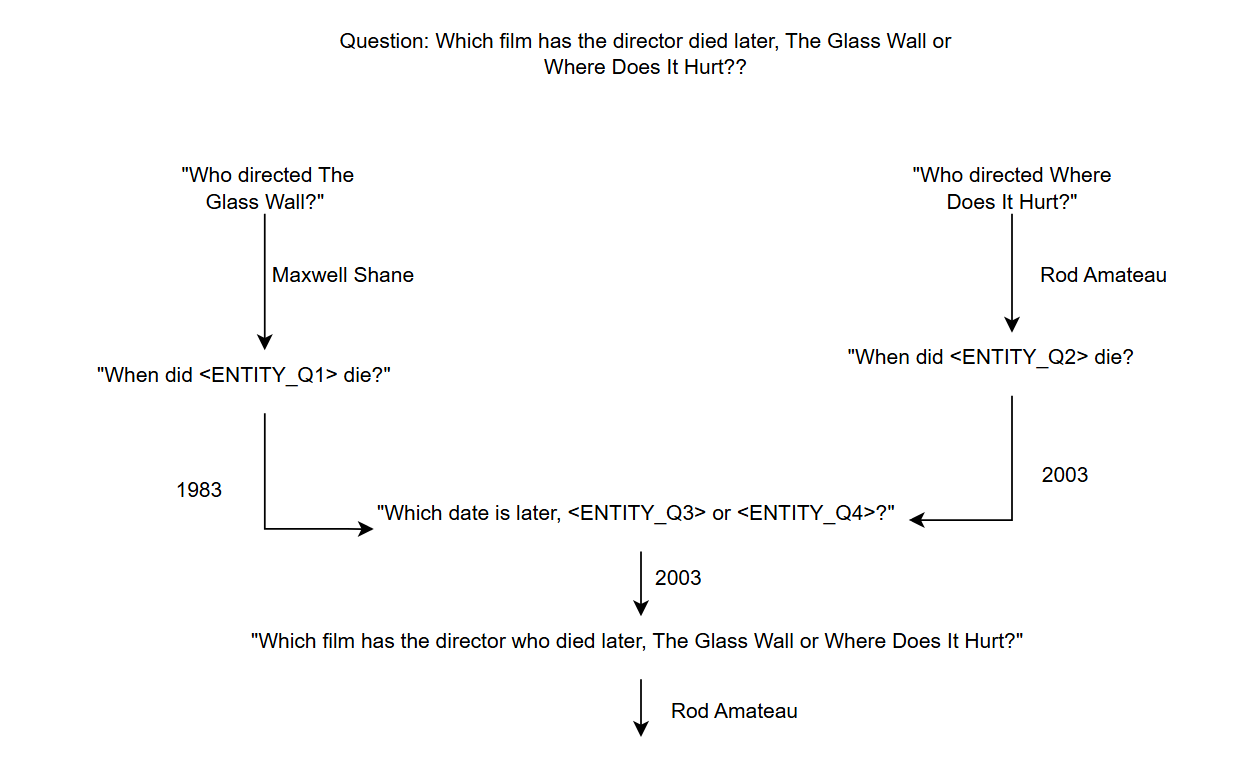

The execution order is Q1/Q2 first, followed by Q3/Q4, and finally Q5. Q5 compares the two retrieved death dates without performing another retrieval. It is therefore a reasoning step: all required facts are already available, and the system only needs to determine which date is later.




## Question 5 — sparse retrieval baselines (12 points)

Evaluate TF–IDF and BM25 for both direct QA retrieval and entity
retrieval followed by local GSW expansion. Use stable QA IDs for
relevance; do not evaluate by comparing array positions.

In [11]:
import collections, difflib, json, math, re, time, unicodedata
import numpy as np, pandas as pd
from panini_course import BM25Index, DualRetriever, TfidfIndex
from panini_course.metrics import recall_at_k, reciprocal_rank

def norm(x):
    x=unicodedata.normalize("NFKD",str(x or ""))
    x="".join(c for c in x if not unicodedata.combining(c))
    return " ".join(re.sub(r"[^\w\s]"," ",x.casefold()).split())

STOP={"the","a","an","of","is","was","were","in","on","at","to","for","and","or","who",
      "what","when","where","which","did","does","do","has","have","had","with","from","by"}

STEM={"directed":"direct","director":"direct","directing":"direct","died":"die","death":"die",
      "born":"birth","birthplace":"birth","released":"release","published":"publish",
      "located":"location","nationality":"country","citizenship":"country","married":"marry",
      "spouse":"marry","wife":"marry","husband":"marry","composed":"compose","composer":"compose",
      "performed":"perform","performer":"perform","founded":"found","buried":"burial"}

def rtokens(x):
    return [STEM.get(t,t) for t in norm(x).split() if t not in STOP]

def overlap(a,b):
    A,B=rtokens(a),rtokens(b)
    if not A: return 0.0
    return sum(max((1.0 if x==y else difflib.SequenceMatcher(None,x,y).ratio())
                    for y in B) for x in A if any(
                        (1.0 if x==y else difflib.SequenceMatcher(None,x,y).ratio())>=.82 for y in B))/len(A)

def load_sparse(root):
    return {
        "qa_tfidf":TfidfIndex.load(root/"indices/qa_tfidf.npz",root/"indices/qa_tfidf_vectorizer.joblib",
                                   root/"indices/qa_ids.json",source="qa_tfidf"),
        "qa_bm25":BM25Index.load(root/"indices/qa_bm25.joblib",root/"indices/qa_ids.json",source="qa_bm25"),
        "entity_bm25":BM25Index.load(root/"indices/entity_bm25.joblib",root/"indices/entity_ids.json",source="entity_bm25"),
    }

sparse={ds:load_sparse(root) for ds,root in PACKAGE_ROOTS.items()}

catalog={}
for ds,pkg in packages.items():
    qa,ent=pkg.qa_pairs(),pkg.entities()
    by_doc=collections.defaultdict(list)
    for r in qa: by_doc[str(r["document_id"])].append(r)
    exp=DualRetriever(entity_index=sparse[ds]["entity_bm25"],qa_index=sparse[ds]["qa_bm25"],
                      entity_rows=ent,qa_rows=qa)
    catalog[ds]={
        "qa":{str(r["qa_uid"]):r for r in qa},
        "entity":{str(r["entity_uid"]):r for r in ent},
        "by_doc":dict(by_doc),
        "entity_qas":exp.qa_ids_by_entity,
    }

def instantiate(text,answers):
    text=str(text or "")
    for pat in (r"#(\d+)",r"<ENTITY_Q(\d+)>"):
        text=re.sub(pat,lambda m:str(answers.get(int(m.group(1)),m.group(0))),text)
    return " ".join(text.split())

def qa_score(query,answer,row,subject="",relation=""):
    text=" ".join([str(row.get("question","")),str(row.get("verb_phrase","")),
                   " ".join(map(str,row.get("answer_names",[]) or [])),
                   " ".join(map(str,row.get("answer_role_states",[]) or []))])
    ans=norm(answer); q=overlap(query,text)
    af=1.0 if ans and ans in norm(text) else overlap(answer,text)
    sf=overlap(subject,row.get("question","")) if subject else 0
    rf=overlap(relation,str(row.get("verb_phrase",""))+" "+str(row.get("question",""))) if relation else 0
    return 6*af+4*sf+2*rf+q, {"answer":af,"subject":sf,"relation":rf,"query":q}

def map_gold(ds,docs,query,answer,subject="",relation=""):
    cat=catalog[ds]; candidates=[]
    for d in docs: candidates += cat["by_doc"].get(str(d),[])
    if not candidates: return {"relevant_qa_ids":[],"mapping_confidence":"unmappable"}
    scored=[(qa_score(query,answer,r,subject,relation),r) for r in candidates]
    scored.sort(key=lambda x:(-x[0][0],str(x[1]["qa_uid"])))
    (score,feat),best=scored[0]
    conf=("high" if feat["answer"]>=.8 and (not subject or feat["subject"]>=.8) and
          (not relation or feat["relation"]>=.8)
          else "medium" if feat["answer"]>=.5 else "low")
    return {
        "relevant_qa_ids":[str(best["qa_uid"])],
        "mapping_confidence":conf,
        "mapping_score":float(score),
        "matched_qa_question":str(best.get("question","")),
        "matched_qa_answers":list(best.get("answer_names",[]) or []),
    }

def build_atomic(ds):
    out=[]
    questions=packages[ds].questions("public")
    if QUESTION_LIMIT is not None: questions=questions[:QUESTION_LIMIT]
    for q in questions:
        prior={}
        for i,e in enumerate(q.get("evidences",[]) or [],1):
            if isinstance(e,dict):
                step=int(e.get("step",i)); query=instantiate(e.get("question",""),prior)
                answer=str(e.get("answer","")); docs=[str(e["document_id"])]
                subject=relation=""
            elif isinstance(e,(list,tuple)) and len(e)>=3:
                step=i; subject,relation,answer=map(str,e[:3]); query=f"{subject} >> {relation}"
                docs=[str(x) for x in q.get("context_document_ids",[])]
            else: raise TypeError(f"Unsupported evidence schema: {e!r}")
            m=map_gold(ds,docs,query,answer,subject,relation)
            out.append({
                "dataset":ds,"outer_question_id":str(q["question_id"]),
                "question_type":q.get("type"),"hop_count":q.get("hop_count",len(q.get("evidences",[]) or [])),
                "step":step,"query":query,"gold_answer":answer,"gold_document_ids":docs,**m
            })
            prior[step]=answer
    return out

atomic_tasks=[t for ds in DATASETS for t in build_atomic(ds)]
print(pd.DataFrame(atomic_tasks).groupby(["dataset","mapping_confidence"]).size())

for t in atomic_tasks:
    t["evaluation_eligible"]=t["mapping_confidence"]!="unmappable"

def retrieve(ds,query,method,k=15):
    cat=catalog[ds]
    if method=="entity_bm25":
        hits=sparse[ds][method].search(query,max(20,k)); seen={}
        for h in hits:
            for uid in cat["entity_qas"].get(str(h.item_id),()):
                key=(int(h.rank),-float(h.score),str(uid))
                if uid not in seen or key<seen[uid][0]: seen[uid]=(key,float(h.score),str(h.item_id))
        ordered=sorted(seen.items(),key=lambda x:(x[1][0],x[0]))[:k]
        return [{
            **cat["qa"][uid],"qa_uid":uid,"score":score,"rank":i+1,"source":method,
            "introduced_entity":eid,
            "matched_terms":sorted(set(rtokens(query))&set(rtokens(cat["entity"][eid].get("search_text",""))))
        } for i,(uid,(_,score,eid)) in enumerate(ordered)]
    return [{
        **cat["qa"][str(h.item_id)],"qa_uid":str(h.item_id),"score":float(h.score),
        "rank":int(h.rank),"source":method,
        "matched_terms":sorted(set(rtokens(query))&set(rtokens(cat["qa"][str(h.item_id)].get("search_text",""))))
    } for h in sparse[ds][method].search(query,k)]

def tiny_test():
    docs=["Who directed The Glass Wall? Maxwell Shane","Who composed The Glass Wall? Leith Stevens",
          "Where was Maxwell Shane born? Paterson New Jersey"]
    q="Who directed The Glass Wall?"
    tf=TfidfVectorizer(ngram_range=(1,2),sublinear_tf=True)
    assert np.argmax((tf.fit_transform(docs)@tf.transform([q]).T).toarray())==0
    bm=BM25Okapi([rtokens(x) for x in docs],k1=1.5,b=.75,epsilon=.25)
    assert np.argmax(bm.get_scores(rtokens(q)))==0
    print("Tiny sparse test: PASS")

from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
tiny_test()

def evaluate(ds,k_values=(1,5,10,15)):
    tasks=[t for t in atomic_tasks if t["dataset"]==ds and t.get("evaluation_eligible",True)]
    rows=[]; traces=[]
    for t in tasks:
        gold=set(map(str,t["relevant_qa_ids"]))
        for method in ("qa_tfidf","qa_bm25","entity_bm25"):
            tic=time.perf_counter(); ranking=retrieve(ds,t["query"],method,max(k_values))
            latency=(time.perf_counter()-tic)*1000; ids=[r["qa_uid"] for r in ranking]
            rows.append({
                "dataset":ds,"outer_question_id":t["outer_question_id"],"question_type":t["question_type"],
                "hop_count":t["hop_count"],"step":t["step"],"query":t["query"],"method":method,
                "Recall@1":recall_at_k(ids,gold,1),"Recall@5":recall_at_k(ids,gold,5),
                "Recall@10":recall_at_k(ids,gold,10),"Recall@15":recall_at_k(ids,gold,15),
                "MRR":reciprocal_rank(ids,gold),"latency_ms":latency,"candidate_count":len(ranking)
            })
            traces.append({**t,"method":method,"latency_ms":latency,"ranking":ranking})
    df=pd.DataFrame(rows); result=[]
    group_col="question_type" if ds=="2wiki" else "hop_count"
    for method,g in df.groupby("method"):
        for label,s in [("overall",g),*[(f"{group_col}={v}",x) for v,x in g.groupby(group_col)]]:
            result.append({"dataset":ds,"method":method,"group":label,"questions":len(s),
                            **{f"Recall@{k}":s[f"Recall@{k}"].mean() for k in k_values},
                            "MRR":s["MRR"].mean(),"mean_latency_ms":s["latency_ms"].mean()})
    return df,pd.DataFrame(result),traces

q5_results={ds:evaluate(ds) for ds in DATASETS}
q5_summary=pd.concat([x[1] for x in q5_results.values()],ignore_index=True)

print("\n--- Q5 Retrieval Results ---")
display(q5_summary.sort_values(["dataset","group","method"]))

def disagreement(traces,n=2):
    groups=collections.defaultdict(dict)
    for t in traces: groups[(t["outer_question_id"],t["step"],t["query"])][t["method"]]=t
    found=[]
    for key,m in groups.items():
        ranks={method:next((r["rank"] for r in t["ranking"] if r["qa_uid"] in set(t["relevant_qa_ids"])),math.inf)
               for method,t in m.items()}
        finite=[r for r in ranks.values() if math.isfinite(r)]
        if finite and len(set(ranks.values()))>1:
            found.append((max([r if math.isfinite(r) else 999 for r in ranks.values()])-min(finite),key,m,ranks))
    return sorted(found,key=lambda x:(-x[0],x[1]))[:n]

q5_disagreements=[]
for ds,(_,_,traces) in q5_results.items():
    for spread,key,methods,ranks in disagreement(traces):
        q5_disagreements.append((ds,key,methods,ranks))
        print(f"\n--- {ds} | {key[2]} ---\nRanks: {ranks}")
        for method,t in methods.items():
            print(method)
            display(pd.DataFrame(t["ranking"][:5])[[
                "rank","qa_uid","score","matched_terms","question","answer_names"
            ]])

# Index parameters are supplied by the course artifacts.
for ds,root in PACKAGE_ROOTS.items():
    manifest=json.loads((root/"indices/index_manifest.json").read_text())
    print(ds,{
        "tfidf_ngram":manifest["tfidf"]["qa"]["ngram_range"],
        "tfidf_sublinear":manifest["tfidf"]["qa"]["sublinear_tf"],
        "bm25_k1":manifest["bm25"]["qa"]["k1"],
        "bm25_b":manifest["bm25"]["qa"]["b"],
        "bm25_epsilon":manifest["bm25"]["qa"]["epsilon"],
    })

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


dataset  mapping_confidence
2wiki    high                   67
         medium                140
musique  high                  208
         low                     7
         medium                  1
dtype: int64
Tiny sparse test: PASS

--- Q5 Retrieval Results ---


,dataset,method,group,questions,Recall@1,Recall@5,Recall@10,Recall@15,MRR,mean_latency_ms
0,2wiki,entity_bm25,overall,207,0.164251,0.565217,0.748792,0.830918,0.323996,5.719213
5,2wiki,qa_bm25,overall,207,0.550725,0.792271,0.908213,0.946860,0.657889,7.731296
10,2wiki,qa_tfidf,overall,207,0.294686,0.758454,0.884058,0.942029,0.498300,2.351242
1,2wiki,entity_bm25,question_type=bridge_comparison,83,0.240964,0.759036,0.843373,0.891566,0.411788,5.819716
6,2wiki,qa_bm25,question_type=bridge_comparison,83,0.698795,0.879518,0.963855,0.987952,0.785585,7.858863
11,2wiki,qa_tfidf,question_type=bridge_comparison,83,0.253012,0.867470,0.987952,0.987952,0.514071,2.375973
2,2wiki,entity_bm25,question_type=comparison,44,0.204545,0.704545,0.909091,0.931818,0.405834,5.881282
7,2wiki,qa_bm25,question_type=comparison,44,0.727273,0.954545,1.000000,1.000000,0.809343,7.917885
12,2wiki,qa_tfidf,question_type=comparison,44,0.500000,0.931818,0.977273,1.000000,0.668939,2.346863
3,2wiki,entity_bm25,question_type=compositional,40,0.125000,0.350000,0.575000,0.675000,0.235716,5.561025



--- 2wiki | Scaregivers >> publication date ---
Ranks: {'qa_tfidf': 1, 'qa_bm25': 1, 'entity_bm25': inf}
qa_tfidf


,rank,qa_uid,score,matched_terms,question,answer_names
0,1,doc_1131::gsw_1131_0.json::v1::q1,0.263130,"[date, scaregivers]",When was Scaregivers released?,[2008]
1,2,doc_1131::gsw_1131_0.json::v1::q2,0.181317,[scaregivers],What film was released in 2008?,[Scaregivers]
2,3,doc_1131::gsw_1131_0.json::v2::q3,0.177742,[scaregivers],Who wrote Scaregivers?,[Jourdan Sebastian]
3,4,doc_1131::gsw_1131_0.json::v3::q5,0.170107,[scaregivers],Who directed Scaregivers?,[Uro Q. dela Cruz]
4,5,doc_4207::gsw_4207_0.json::v7::q16,0.170001,[publication],What publication does Joel Poblete write for?,[Mabuse]


...

qa_bm25


,rank,qa_uid,score,matched_terms,question,answer_names
0,1,doc_6286::gsw_6286_0.json::v2::q4,25.491776,"[be, let, love, there]",What was recorded in 1953?,[Let There Be Love (Let There Be Love (1953 Jo...
1,2,doc_6286::gsw_6286_0.json::v1::q2,25.042816,"[be, let, love, there]",What album did Joni James record?,[Let There Be Love (Let There Be Love (1953 Jo...
2,3,doc_6285::gsw_6285_0.json::v2::q4,25.042816,"[be, let, love, there]",What album did Jasmine Records release?,[Let There Be Love (Let There Be Love (1993 Jo...
3,4,doc_6285::gsw_6285_0.json::v1::q2,25.042816,"[be, let, love, there]",What album did Joni James record?,[Let There Be Love (Let There Be Love (1993 Jo...
4,5,doc_6286::gsw_6286_0.json::v3::q6,25.042816,"[be, let, love, there]",What album did MGM Records release?,[Let There Be Love (Let There Be Love (1953 Jo...


entity_bm25


,rank,qa_uid,score,matched_terms,question,answer_names
0,1,doc_6285::gsw_6285_0.json::v1::q1,26.353767,"[be, let, love, there]",Who recorded 'Let There Be Love'?,[Joni James]
1,2,doc_6285::gsw_6285_0.json::v1::q2,26.353767,"[be, let, love, there]",What album did Joni James record?,[Let There Be Love (Let There Be Love (1993 Jo...
2,3,doc_6285::gsw_6285_0.json::v2::q3,26.353767,"[be, let, love, there]",Who released 'Let There Be Love'?,[Jasmine Records]
3,4,doc_6285::gsw_6285_0.json::v2::q4,26.353767,"[be, let, love, there]",What album did Jasmine Records release?,[Let There Be Love (Let There Be Love (1993 Jo...
4,5,doc_6285::gsw_6285_0.json::v3::q5,26.353767,"[be, let, love, there]",When was 'Let There Be Love' released?,"[March 1, 1993]"


2wiki {'tfidf_ngram': [1, 2], 'tfidf_sublinear': True, 'bm25_k1': 1.5, 'bm25_b': 0.75, 'bm25_epsilon': 0.25}
musique {'tfidf_ngram': [1, 2], 'tfidf_sublinear': True, 'bm25_k1': 1.5, 'bm25_b': 0.75, 'bm25_epsilon': 0.25}


### Your written response for Question 5

Across both datasets, BM25 generally retrieved the correct QA pair more reliably than TF–IDF, particularly when the correct result needed to appear near the top of the ranking. On 2Wiki, BM25 achieved Recall@1 of 0.551 and MRR of 0.658, compared with 0.295 and 0.498 for TF–IDF. This difference is clear in the `Bommarillu Bhaskar >> award received` example, where BM25 ranked the correct award question first while TF–IDF ranked it seventh. BM25 handles repeated query terms while accounting for document length, allowing important words such as “award,” “Bhaskar,” and “Bommarillu” to contribute strongly without giving longer records an automatic advantage.

TF–IDF remained competitive when the correct result was allowed to appear deeper in the ranking. On 2Wiki, Recall@15 was 0.942 for TF–IDF and 0.947 for BM25. On MuSiQue, the gap was larger, with Recall@15 of 0.699 for TF–IDF compared with 0.792 for BM25. Document frequency also matters because common words such as “let,” “there,” and “love” appear in many records and therefore provide less useful separation. This is visible in the `Let There Be Love >> performer` example, where both QA methods were distracted by repeated title wording. Entity BM25 ranked the correct result first by matching the entity and expanding to its connected QA records, showing how entity information can recover relationships that purely lexical retrieval may miss.


## Question 6 — dense, hybrid, and paper-style dual retrieval (16 points)

All corpus and required query embeddings are supplied. Load them by
stable ID and exact query text. A missing required query means your
deterministic plan or RICR path diverged; it is not permission to
generate a new embedding.

In [12]:
from panini_course import DenseIndex, DualRetriever, QueryEmbeddingStore, reciprocal_rank_fusion

def bm25_qa(ds,query,k=15):
    """Return QA candidates using the supplied BM25 QA index."""
    hits=sparse[ds]["qa_bm25"].search(query,k)
    return qa_rows_from_hits(ds,hits,"qa_bm25")

def retrieve_candidate_pool(dataset,query,pool_size=60,backend="dual"):
    """
    Common retrieval interface used by Q9.

    Q6 already implements the actual dense/RRF/dual retrieval
    mechanisms; this function only exposes them through the
    interface expected by the ablation runner.
    """
    backend=str(backend).casefold()
    if backend=="bm25":
        return bm25_qa(dataset,query,k=pool_size)
    if backend=="dense":
        return dense_qa(dataset,query,k=pool_size)
    if backend=="rrf":
        return rrf_qa(dataset,query,k=pool_size)
    if backend=="dual":
        return dual_qa(dataset,query,k=pool_size)
    raise ValueError(f"Unknown retrieval backend: {backend}")

In [13]:
import json, math, time, collections
import numpy as np
import pandas as pd
from panini_course import DenseIndex, QueryEmbeddingStore, reciprocal_rank_fusion

ENTITY_TOP_K = 20

def load_dense(root):
    return {
        "queries": QueryEmbeddingStore.load(
            root/"embeddings/query_embeddings.npy",
            root/"embeddings/query_ids.json",
            root/"embeddings/queries.jsonl"),
        "qa": DenseIndex.load(
            root/"indices/qa_qwen3_8b_ip.faiss",
            root/"indices/qa_ids.json",
            source="qa_dense"),
    }

dense = {ds: load_dense(root) for ds,root in PACKAGE_ROOTS.items()}

class MissingQueryEmbeddingError(KeyError):
    pass

def query_vector(ds, query):
    try: return np.asarray(dense[ds]["queries"].get(query), dtype=np.float32)
    except KeyError as e: raise MissingQueryEmbeddingError(str(e)) from e

def qa_rows_from_hits(dataset, hits, source):
    cat = catalog[dataset]
    rows = []
    for h in hits:
        uid = str(h.item_id)
        row = cat["qa"].get(uid)
        if row is None:
            continue
        rows.append({
            **row,
            "qa_uid": uid,
            "score": float(h.score),
            "rank": int(h.rank),
            "source": source,
            "routes": [source],
            "route_ranks": {source: int(h.rank)},
        })
    return rows

def dense_qa(ds, query, k=15):
    return qa_rows_from_hits(ds, dense[ds]["qa"].search(query_vector(ds,query),k), "qa_dense")

def rrf_qa(ds, query, k=60):
    rankings = [
        sparse[ds]["qa_tfidf"].search(query,k),
        sparse[ds]["qa_bm25"].search(query,k),
        dense[ds]["qa"].search(query_vector(ds,query),k),
    ]
    hits = reciprocal_rank_fusion(rankings, rank_constant=RRF_CONSTANT, top_k=k)
    rows = qa_rows_from_hits(ds,hits,"rrf")
    for row,hit in zip(rows,hits):
        srcs=list(hit.metadata.get("fusion_sources",()))
        row["routes"]=srcs
        row["route_ranks"]={s:next(h.rank for r in rankings for h in r if h.item_id==hit.item_id and h.source==s)
                            for s in srcs}
        row["best_pre_rank"]=min(row["route_ranks"].values())
    return rows

def retrieve_entity_expansion(dataset, query, method="entity_bm25", top_k=60, entity_top_k=20):
    hits = sparse[dataset][method].search(query, entity_top_k)
    cat = catalog[dataset]
    best = {}

    for h in hits:
        eid = str(h.item_id)
        for uid in cat["entity_qas"].get(eid, ()):
            key = (int(h.rank), -float(h.score), eid, str(uid))
            if uid not in best or key < best[uid][0]:
                best[uid] = (key, eid, int(h.rank), float(h.score))

    ordered = sorted(best.items(), key=lambda x: (x[1][0], x[0]))[:top_k]
    rows = []

    for rank, (uid, (_, eid, erank, escore)) in enumerate(ordered, 1):
        qa = cat["qa"][str(uid)]
        ent = cat["entity"].get(eid, {})
        rows.append({
            **qa,
            "qa_uid": str(uid),
            "score": escore,
            "rank": rank,
            "source": f"{method}_expand",
            "routes": [f"{method}_expand"],
            "route_ranks": {f"{method}_expand": rank},
            "introduced_by_entity_uid": eid,
            "introduced_by_entity_name": ent.get("name", ""),
            "entity_rank": erank,
        })

    return rows

def dual_qa(ds, query, k=60):
    routes={
        "qa_dense":dense_qa(ds,query,k),
        "entity_bm25_expand":retrieve_entity_expansion(
            ds,query,method="entity_bm25",top_k=k,entity_top_k=ENTITY_TOP_K)
    }
    merged={}
    for route,rows in routes.items():
        for row in rows:
            uid=str(row["qa_uid"])
            item=merged.setdefault(uid,{"row":dict(row),"ranks":{},"scores":{}})
            item["ranks"][route]=int(row["rank"])
            item["scores"][route]=float(row["score"])
    order=sorted(
        merged.items(),
        key=lambda x:(min(x[1]["ranks"].values()),
                      -len(x[1]["ranks"]),
                      -sum(1/(RRF_CONSTANT+r) for r in x[1]["ranks"].values()),
                      x[0])
    )[:k]
    out=[]
    for rank,(uid,item) in enumerate(order,1):
        best=min(item["ranks"].values())
        out.append({
            **item["row"],"qa_uid":uid,"rank":rank,"score":1/best,
            "source":"dual","routes":sorted(item["ranks"]),
            "route_ranks":item["ranks"],"route_scores":item["scores"],
            "best_pre_rank":best})
    return out

def q6_pool(ds,query,k=60):
    name=str(query).casefold()
    if name in {"dense","qa_dense"}: return dense_qa(ds,query,k)
    if name=="rrf": return rrf_qa(ds,query,k)
    if name=="dual": return dual_qa(ds,query,k)
    raise ValueError(f"Unknown backend: {query}")

def check_query_coverage():
    rows=[]
    for ds in DATASETS:
        tasks=[t for t in atomic_tasks if t["dataset"]==ds]
        missing=[t["query"] for t in tasks
                 if not _query_available(ds,t["query"])]
        rows.append({
            "dataset":ds,
            "atomic_queries":len(tasks),
            "missing_embeddings":len(missing),
            "examples":missing[:5]
        })
        if missing and QUESTION_LIMIT is None:
            raise MissingQueryEmbeddingError(
                f"{ds}: {len(missing)} required queries lack supplied embeddings"
            )
    frame=pd.DataFrame(rows)
    display(frame)
    return frame

def _query_available(ds,q):
    try:
        query_vector(ds,q)
        return True
    except MissingQueryEmbeddingError:
        return False

q6_query_coverage=check_query_coverage()

def _load_json_list(path):
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError(f"Expected JSON list: {path}")
    return [str(x) for x in data]

def manual_dense_search(root,vector,k=5,block=512):
    matrix=np.load(root/"embeddings/qa_embeddings.npy",mmap_mode="r")
    ids=_load_json_list(root/"embeddings/qa_ids.json")
    q=np.asarray(vector,dtype=np.float32).reshape(-1)
    q/=max(np.linalg.norm(q),1e-12)
    best=[]
    for start in range(0,len(matrix),block):
        stop=min(start+block,len(matrix))
        X=np.asarray(matrix[start:stop],dtype=np.float32)
        X/=np.maximum(np.linalg.norm(X,axis=1,keepdims=True),1e-12)
        scores=X@q
        take=min(k,len(scores))
        idx=np.argpartition(-scores,take-1)[:take]
        best.extend((float(scores[i]),ids[start+int(i)]) for i in idx)
        best=sorted(best,key=lambda z:(-z[0],z[1]))[:k]
    return best

def verify_dense(n=5):
    chosen=[]
    seen=set()
    for ds in DATASETS:
        for t in atomic_tasks:
            if t["dataset"]==ds and t["query"] not in seen:
                chosen.append(t); seen.add(t["query"])
            if len(chosen)==n: break
        if len(chosen)==n: break

    rows=[]
    for t in chosen:
        ds=t["dataset"]; qv=query_vector(ds,t["query"])
        faiss=dense[ds]["qa"].search(qv,5)
        manual=manual_dense_search(PACKAGE_ROOTS[ds],qv,5)
        fi=[h.item_id for h in faiss]
        mi=[uid for _,uid in manual]
        rows.append({
            "dataset":ds,"query":t["query"],
            "faiss_top1":fi[0],"manual_top1":mi[0],
            "top1_match":fi[0]==mi[0],
            "top5_overlap":len(set(fi)&set(mi)),
            "faiss_score":float(faiss[0].score),
            "manual_score": {str(uid): score for score, uid in manual}.get(str(fi[0]), np.nan)
        })
    out=pd.DataFrame(rows)
    assert len(out)==n and out.top1_match.all()
    display(out)
    return out

q6_faiss_check=verify_dense()

def retrieval_metrics(ranking, relevant_ids, k_values=(1,5,10,15)):
    ids=[str(r["qa_uid"]) for r in ranking]
    relevant={str(x) for x in relevant_ids}
    return {
        **{f"recall@{k}":recall_at_k(ids,relevant,k) for k in k_values},
        "rr":reciprocal_rank(ids,relevant),
        "first_relevant_rank":next(
            (i for i,x in enumerate(ids,1) if x in relevant), None
        ),
    }

def evaluate_q6(ds,kvals=(1,5,10,15)):
    tasks=[t for t in atomic_tasks if t["dataset"]==ds]
    methods=("dense","rrf","dual")
    records=[]; traces=[]

    for t in tasks:
        relevant=set(map(str,t.get("relevant_qa_ids",[])))
        eligible=t.get("evaluation_eligible",True)

        for method in methods:
            tic=time.perf_counter()
            ranking=q6_pool(ds,t["query"],60,method) if False else {
                "dense":lambda:dense_qa(ds,t["query"],60),
                "rrf":lambda:rrf_qa(ds,t["query"],60),
                "dual":lambda:dual_qa(ds,t["query"],60)
            }[method]()
            latency=(time.perf_counter()-tic)*1000
            ids=[str(r["qa_uid"]) for r in ranking]

            if eligible:
                m=retrieval_metrics(ranking,relevant,kvals)
                records.append({
                    "dataset":ds,"outer_question_id":t["outer_question_id"],
                    "question_type":t["question_type"],"hop_count":t["hop_count"],
                    "step":t["step"],"query":t["query"],"method":method,
                    "latency_ms":latency,"candidate_count":len(ranking),
                    "evaluation_scope":"qa_mappable_only",**m
                })

            traces.append({
                **t,"method":method,"latency_ms":latency,
                "ranking":[{
                    "qa_uid":str(r["qa_uid"]),"rank":r["rank"],"score":r["score"],
                    "routes":r.get("routes",[r.get("source")]),
                    "route_ranks":r.get("route_ranks",{}),
                    "question":r.get("question",""),
                    "answer_names":r.get("answer_names",[]),
                    "relevant":str(r["qa_uid"]) in relevant if eligible else None
                } for r in ranking[:15]]
            })

    df=pd.DataFrame(records)
    group_col="question_type" if ds=="2wiki" else "hop_count"
    summary=[]

    for method,g in df.groupby("method"):
        for label,s in [("overall",g),*[(f"{group_col}={v}",x) for v,x in g.groupby(group_col)]]:
            summary.append({
                "dataset":ds,"method":method,"group":label,
                "questions":len(s),"MRR":s["rr"].mean(),
                "mean_latency_ms":s["latency_ms"].mean(),
                "p95_latency_ms":s["latency_ms"].quantile(.95),
                "mean_candidates":s["candidate_count"].mean(),
                **{f"Recall@{k}":s[f"recall@{k}"].mean() for k in kvals}
            })

    path=WORK_ROOT/"retrieval"/ds/"q6_top15_traces.jsonl"
    path.parent.mkdir(parents=True,exist_ok=True)
    with path.open("w",encoding="utf-8") as f:
        for row in traces: f.write(json.dumps(row,ensure_ascii=False)+"\n")

    return df,pd.DataFrame(summary),traces,path

q6_results={ds:evaluate_q6(ds) for ds in DATASETS}
q6_summary=pd.concat([x[1] for x in q6_results.values()],ignore_index=True)

print("\n--- Q6 Retrieval Results ---")
display(q6_summary.sort_values(["dataset","group","method"]))

def find_dual_gain(traces):
    groups=collections.defaultdict(dict)
    for t in traces:
        groups[(t["outer_question_id"],t["step"],t["query"])][t["method"]]=t

    for key,m in groups.items():
        if not {"dense","dual"}<=set(m): continue
        dr=next((x["rank"] for x in m["dense"]["ranking"] if x["relevant"]),math.inf)
        qr=next((x["rank"] for x in m["dual"]["ranking"] if x["relevant"]),math.inf)
        if qr<=15 and qr<dr:
            return m["dual"],{"dense_rank":dr,"dual_rank":qr}
    return None,None

for ds,(_,_,traces,_) in q6_results.items():
    trace,ranks=find_dual_gain(traces)
    if trace:
        print(f"\n--- Dual-helped query: {ds} ---\n{trace['query']}\n{ranks}")
        display(pd.DataFrame(trace["ranking"])[
            ["rank","qa_uid","routes","route_ranks","relevant","question","answer_names"]
        ])

,dataset,atomic_queries,missing_embeddings,examples
0,2wiki,207,0,[]
1,musique,216,0,[]


,dataset,query,faiss_top1,manual_top1,top1_match,top5_overlap,faiss_score,manual_score
0,2wiki,The Glass Wall >> director,doc_879::gsw_879_0.json::v1::q2,doc_879::gsw_879_0.json::v1::q2,True,5,0.698572,0.696797
1,2wiki,Where Does It Hurt? >> director,doc_876::gsw_876_0.json::v2::q3,doc_876::gsw_876_0.json::v2::q3,True,5,0.666309,0.664479
2,2wiki,Maxwell Shane >> date of death,doc_881::gsw_881_0.json::v3::q6,doc_881::gsw_881_0.json::v3::q6,True,5,0.834750,0.836814
3,2wiki,Rod Amateau >> date of death,doc_877::gsw_877_0.json::v3::q7,doc_877::gsw_877_0.json::v3::q7,True,5,0.806129,0.803368
4,2wiki,House of Blackmail >> director,doc_3171::gsw_3171_0.json::v2::q3,doc_3171::gsw_3171_0.json::v2::q3,True,5,0.722650,0.724431



--- Q6 Retrieval Results ---


,dataset,method,group,questions,MRR,mean_latency_ms,p95_latency_ms,mean_candidates,Recall@1,Recall@5,Recall@10,Recall@15
0,2wiki,dense,overall,207,0.776026,7.409504,7.507809,60.0,0.647343,0.937198,0.966184,0.975845
5,2wiki,dual,overall,207,0.673493,13.984672,16.819473,60.0,0.502415,0.927536,0.971014,0.980676
10,2wiki,rrf,overall,207,0.714234,19.209465,23.258320,60.0,0.589372,0.874396,0.951691,0.975845
1,2wiki,dense,question_type=bridge_comparison,83,0.852022,7.531323,7.564777,60.0,0.759036,0.975904,1.000000,1.000000
6,2wiki,dual,question_type=bridge_comparison,83,0.804246,14.175986,16.195295,60.0,0.698795,0.975904,1.000000,1.000000
11,2wiki,rrf,question_type=bridge_comparison,83,0.854552,19.444102,22.935527,60.0,0.759036,0.975904,0.987952,0.987952
2,2wiki,dense,question_type=comparison,44,0.835985,7.374291,7.488517,60.0,0.704545,1.000000,1.000000,1.000000
7,2wiki,dual,question_type=comparison,44,0.720328,14.222950,16.769755,60.0,0.545455,0.977273,1.000000,1.000000
12,2wiki,rrf,question_type=comparison,44,0.829951,19.594386,22.955718,60.0,0.750000,0.954545,1.000000,1.000000
3,2wiki,dense,question_type=compositional,40,0.677258,7.317166,7.393490,60.0,0.525000,0.825000,0.900000,0.925000



--- Dual-helped query: 2wiki ---
The Glass Wall >> director
{'dense_rank': 3, 'dual_rank': 2}


,rank,qa_uid,routes,route_ranks,relevant,question,answer_names
0,1,doc_879::gsw_879_0.json::v1::q2,"[entity_bm25_expand, qa_dense]","{'qa_dense': 1, 'entity_bm25_expand': 2}",False,What film did Maxwell Shane direct?,[The Glass Wall]
1,2,doc_879::gsw_879_0.json::v1::q1,"[entity_bm25_expand, qa_dense]","{'qa_dense': 3, 'entity_bm25_expand': 1}",True,Who directed The Glass Wall?,[Maxwell Shane]
2,3,doc_879::gsw_879_0.json::v6::q12,"[entity_bm25_expand, qa_dense]","{'qa_dense': 2, 'entity_bm25_expand': 10}",False,Which film won the Golden Leopard?,[The Glass Wall]
3,4,doc_879::gsw_879_0.json::v2::q3,"[entity_bm25_expand, qa_dense]","{'qa_dense': 9, 'entity_bm25_expand': 3}",False,Who starred in The Glass Wall?,"[Vittorio Gassman, Gloria Grahame]"
4,5,doc_879::gsw_879_0.json::v2::q4,"[entity_bm25_expand, qa_dense]","{'qa_dense': 6, 'entity_bm25_expand': 4}",False,In what film did Vittorio Gassman and Gloria G...,[The Glass Wall]
5,6,doc_879::gsw_879_0.json::v3::q6,"[entity_bm25_expand, qa_dense]","{'qa_dense': 4, 'entity_bm25_expand': 6}",False,What film did Columbia Pictures produce and di...,[The Glass Wall]
6,7,doc_879::gsw_879_0.json::v3::q5,"[entity_bm25_expand, qa_dense]","{'qa_dense': 5, 'entity_bm25_expand': 5}",False,Who produced and distributed The Glass Wall?,[Columbia Pictures]
7,8,doc_879::gsw_879_0.json::v4::q8,"[entity_bm25_expand, qa_dense]","{'qa_dense': 7, 'entity_bm25_expand': 8}",False,Which film's title refers to the United Nation...,[The Glass Wall]
8,9,doc_879::gsw_879_0.json::v4::q7,"[entity_bm25_expand, qa_dense]","{'qa_dense': 10, 'entity_bm25_expand': 7}",False,What does the title of The Glass Wall refer to?,[United Nations headquarters]
9,10,doc_879::gsw_879_0.json::v6::q11,"[entity_bm25_expand, qa_dense]","{'qa_dense': 8, 'entity_bm25_expand': 9}",False,What award did The Glass Wall win?,[Golden Leopard]



--- Dual-helped query: musique ---
Julian P. Kanter Political Commercial Archive >> part of
{'dense_rank': 4, 'dual_rank': 2}


,rank,qa_uid,routes,route_ranks,relevant,question,answer_names
0,1,doc_1827::gsw_1827_0.json::v2::q3,"[entity_bm25_expand, qa_dense]","{'qa_dense': 1, 'entity_bm25_expand': 3}",False,What archive has been designated as an officia...,[Julian P. Kanter Political Commercial Archive]
1,2,doc_1827::gsw_1827_0.json::v1::q1,"[entity_bm25_expand, qa_dense]","{'qa_dense': 4, 'entity_bm25_expand': 1}",True,Where is the Julian P. Kanter Political Commer...,[University of Oklahoma]
2,3,doc_1827::gsw_1827_0.json::v1::q2,"[entity_bm25_expand, qa_dense]","{'qa_dense': 2, 'entity_bm25_expand': 2}",False,What archive is located at the University of O...,[Julian P. Kanter Political Commercial Archive]
3,4,doc_1827::gsw_1827_0.json::v2::q4,"[entity_bm25_expand, qa_dense]","{'qa_dense': 3, 'entity_bm25_expand': 4}",False,Which organization designated the Julian P. Ka...,[Save America's Treasures]
4,5,doc_1824::gsw_1824_0.json::v3::q6,"[entity_bm25_expand, qa_dense]","{'qa_dense': 5, 'entity_bm25_expand': 16}",False,Who was a member of the Liberal party?,[Ronald M. Kanter (Ron Kanter)]
5,6,doc_1818::gsw_1818_0.json::v1::q1,[entity_bm25_expand],{'entity_bm25_expand': 5},False,Where is the Walter P. Reuther Library located?,[Wayne State University]
6,7,doc_1824::gsw_1824_0.json::v2::q3,"[entity_bm25_expand, qa_dense]","{'qa_dense': 6, 'entity_bm25_expand': 13}",False,Who served in the Legislative Assembly of Onta...,[Ronald M. Kanter (Ron Kanter)]
7,8,doc_1818::gsw_1818_0.json::v1::q2,[entity_bm25_expand],{'entity_bm25_expand': 6},False,What is located on the campus of Wayne State U...,"[Walter P. Reuther Library, Archives of Labor ..."
8,9,doc_1824::gsw_1824_0.json::v4::q8,"[entity_bm25_expand, qa_dense]","{'qa_dense': 7, 'entity_bm25_expand': 18}",False,Who served from 1987 to 1990 in the Legislativ...,[Ronald M. Kanter (Ron Kanter)]
9,10,doc_1818::gsw_1818_0.json::v3::q5,[entity_bm25_expand],{'entity_bm25_expand': 7},False,What does the Walter P. Reuther Library contai...,[United States]


### Your written response for Question 6

The measured results show that dense retrieval was the strongest overall approach. On 2Wiki, dense retrieval achieved Recall@1 of 0.647 and MRR of 0.776, compared with 0.502 and 0.673 for dual retrieval and 0.589 and 0.714 for RRF. The same pattern appeared on MuSiQue, where dense reached Recall@15 of 0.903 compared with 0.898 for dual and 0.838 for RRF. Dense retrieval was also substantially faster in terms of latency.

Entity expansion was still useful on individual queries because it could connect an entity directly to related QA records. For `The Glass Wall >> director`, entity-BM25 expansion ranked the correct QA first, while dense ranked it third, allowing dual retrieval to move it to second. However, this did not improve the overall results, suggesting that entity expansion can also introduce distracting QA records.

Dense QA search and entity expansion do not produce the same pool because they search different representations. Dense retrieval compares the query with the semantic content of QA records, while entity expansion retrieves entities and then adds the QA records connected to those entities. As a result, one method can find a QA pair because its wording is semantically similar to the query, while the other can find related QA pairs through an entity even when the QA wording is quite different.

The retrieval-pool evidence shows that the candidate pool itself can cause failures before reranking. In the `Let There Be Love >> performer` example, the correct QA was not returned by the QA TF-IDF pool at all, so reranking could not recover it. Evidently, reranking can only reorder candidates already retrieved and cannot fix a missing candidate. Overall, dense retrieval provided the best balance of accuracy, coverage, and latency, while RRF and dual retrieval offered occasional query-level gains at a higher computational cost.



## Stage B — Question 7: reranking without exceeding Colab memory (8 points)

The reranker is the only neural model in this stage. Use the 8B
checkpoint in 4-bit mode when it fits; after an actual CUDA OOM,
clear memory and use the configured 4B fallback with batch size 1
and 256-token inputs. Cache rankings by exact instantiated query so
RICR replay and ablations do not rerun the same model call.

In [14]:
from panini_course import Candidate

Q7_ACTIVE_MODE = None
Q7_MODEL_NAME = None
Q7_BATCH = 1
Q7_CACHE = {}

def rerank_and_convert(dataset, query, reranker, *, top_k=CANDIDATES_PER_HOP):
    mode = Q7_ACTIVE_MODE
    if mode is None:
        mode = "hybrid"

    model_name = Q7_MODEL_NAME or reranker.model.config._name_or_path
    key = (dataset, model_name)

    if key not in Q7_CACHE:
        Q7_CACHE[key] = RerankerScoreCache(
            WORK_ROOT / "cache" / dataset / "q7_reranker_scores.jsonl",
            model_name,
        )

    pool = dual_qa(dataset, query, RETRIEVAL_POOL)
    scores, _ = _rerank_scores(
        query, pool, reranker, Q7_CACHE[key], Q7_BATCH
    )
    ranked = _rank_q7(pool, scores, mode)[:top_k]

    from panini_course.ricr import Candidate

    return [
        Candidate(
            qa_uid=str(r["qa_uid"]),
            answer_names=tuple(map(str, r.get("answer_names", []) or [])),
            score=float(r["final_score"]),
            question=str(r.get("question", "")),
            answer_ids=namespace_answer_ids(r),
            answer_role_states=tuple(map(str, r.get("answer_role_states", []) or [])),
            document_id=str(r.get("document_id", "")),
            metadata={
                "gsw_file": str(r.get("gsw_file", "")),
                "verb_phrase_id": str(r.get("verb_phrase_id", "")),
                "routes": list(r.get("routes", [])),
                "route_ranks": dict(r.get("route_ranks", {})),
                "pre_rank": int(r["pre_rank"]),
                "reranker_probability": float(r["reranker_probability"]),
                "reciprocal_pre_rank": float(r["reciprocal_pre_rank"]),
                "score_mode": mode,
            },
        )
        for r in ranked
    ]

def choose_reranker_config(model_cfg):
    try:
        import torch
        total_gib = torch.cuda.get_device_properties(0).total_memory / 2**30
    except Exception:
        total_gib = 0.0
    use_8b = total_gib >= model_cfg['reranker']['use_8b_at_or_above_gib']
    return {
        'model': (model_cfg['reranker']['model'] if use_8b
                  else model_cfg['reranker']['free_colab_t4_fallback']),
        'batch_size': 1 if total_gib < 20 else 8,
        'max_length': 256 if total_gib < 20 else 2048,
        'total_gib': total_gib,
    }

In [15]:
import hashlib, json, math, time
from pathlib import Path
from panini_course.qwen_models import QwenReranker

def format_qa_for_reranker(qa_row):
    q = str(qa_row.get("question", "")).strip()
    a = "; ".join(map(str, qa_row.get("answer_names", []) or []))
    r = "; ".join(map(str, qa_row.get("answer_role_states", []) or []))
    return f"Q: {q}\nA: {a}\nAnswer roles/states: {r}"

def namespace_answer_ids(qa_row):
    doc, gsw = str(qa_row.get("document_id", "")), str(qa_row.get("gsw_file", ""))
    return tuple(x if "::" in x else f"{doc}::{gsw}::{x}"
                 for x in map(str, qa_row.get("answer_local_ids", []) or []))

def _pool_signature(pool):
    return hashlib.sha256(
        "\n".join(str(x["qa_uid"]) for x in pool).encode()
    ).hexdigest()

class RerankerScoreCache:
    def __init__(self, path, model_name):
        self.path, self.model_name = Path(path), str(model_name)
        self.rows = {}
        if self.path.exists():
            for row in read_jsonl(self.path):
                key = (str(row.get("model_name")), str(row.get("query")),
                       str(row.get("pool_signature")))
                self.rows[key] = row

    def get(self, query, pool):
        key = (self.model_name, str(query), _pool_signature(pool))
        row = self.rows.get(key)
        if row is None:
            return None
        scores = {str(k): float(v) for k, v in row.get("scores", {}).items()}
        return scores if set(scores) == {str(x["qa_uid"]) for x in pool} else None

    def put(self, query, pool, scores):
        row = {
            "model_name": self.model_name,
            "query": str(query),
            "pool_signature": _pool_signature(pool),
            "qa_ids": [str(x["qa_uid"]) for x in pool],
            "scores": {str(k): float(v) for k, v in scores.items()},
        }
        append_jsonl(self.path, row)
        self.rows[(self.model_name, str(query), row["pool_signature"])] = row

def _rerank_scores(query, pool, reranker, cache, batch_size=1):
    cached = cache.get(query, pool)
    if cached is not None:
        return cached, True

    probs = reranker.score(
        query,
        [format_qa_for_reranker(x) for x in pool],
        batch_size=batch_size,
    )
    if len(probs) != len(pool):
        raise RuntimeError(f"Expected {len(pool)} scores, got {len(probs)}")

    scores = {str(row["qa_uid"]): float(p)
              for row, p in zip(pool, probs)}
    cache.put(query, pool, scores)
    return scores, False

def _rank_q7(pool, scores, mode):
    mode = str(mode).casefold()
    weights = {"reranker": (1, 0), "retrieval": (0, 1), "hybrid": (.5, .5)}
    if mode not in weights:
        raise ValueError(f"Unknown Q7 mode: {mode}")

    a, b = weights[mode]
    ranked = []

    for row in pool:
        uid = str(row["qa_uid"])
        pre = int(row.get("best_pre_rank", row.get("rank", 1)))
        rr, rp = 1.0 / pre, float(scores[uid])
        ranked.append({
            **row,
            "pre_rank": pre,
            "reciprocal_pre_rank": rr,
            "reranker_probability": rp,
            "final_score": a * rp + b * rr,
            "score_mode": mode,
        })

    ranked.sort(key=lambda x: (-x["final_score"], x["pre_rank"], str(x["qa_uid"])))
    for i, row in enumerate(ranked, 1):
        row.update(rank=i, score=row["final_score"], source=f"dual_{mode}")
    return ranked

def choose_reranker_config(model_cfg):
    import torch
    cfg = model_cfg["reranker"]
    if not torch.cuda.is_available():
        raise RuntimeError("Q7 reranking requires a CUDA GPU.")
    return {
        "model": cfg["model"],
        "batch_size": cfg["free_colab_batch_size"],
        "max_length": cfg["free_colab_max_length"],
        "total_gib": torch.cuda.get_device_properties(0).total_memory / 2**30,
        "selection_policy": "8B_then_4B_on_oom",
    }

def evaluate_q7_dataset(dataset, reranker, model_name, batch_size=1):
    tasks = [t for t in atomic_tasks if t["dataset"] == dataset]
    cache = RerankerScoreCache(
        WORK_ROOT / "cache" / dataset / "q7_reranker_scores.jsonl", model_name
    )
    records, traces = [], []

    for i, task in enumerate(tasks, 1):
        if i == 1 or i % 10 == 0 or i == len(tasks):
            print(f"[Q7 {dataset}] {i}/{len(tasks)}: {task['query']}", flush=True)

        t0 = time.perf_counter()
        pool = dual_qa(dataset, task["query"], RETRIEVAL_POOL)
        pool_ms = (time.perf_counter() - t0) * 1000

        assert len(pool) <= RETRIEVAL_POOL
        assert len({str(x["qa_uid"]) for x in pool}) == len(pool)

        t1 = time.perf_counter()
        scores, cache_hit = _rerank_scores(
            task["query"], pool, reranker, cache, batch_size
        )
        score_ms = (time.perf_counter() - t1) * 1000

        relevant = {str(x) for x in task.get("relevant_qa_ids", [])}
        rankings = {}

        for mode in ("reranker", "retrieval", "hybrid"):
            ranking = _rank_q7(pool, scores, mode)
            rankings[mode] = ranking

            if task.get("evaluation_eligible", True):
                m = retrieval_metrics(ranking, relevant, (15,))
                records.append({
                    "dataset": dataset,
                    "outer_question_id": task["outer_question_id"],
                    "question_type": task["question_type"],
                    "hop_count": task["hop_count"],
                    "step": task["step"],
                    "query": task["query"],
                    "mode": mode,
                    "Recall@15": m["recall@15"],
                    "MRR": m["rr"],
                    "first_relevant_rank": m["first_relevant_rank"],
                    "candidate_count": len(pool),
                    "pool_recall": recall_at_k(
                        [str(x["qa_uid"]) for x in pool], relevant, len(pool)
                    ),
                    "pool_ms": pool_ms,
                    "score_ms": score_ms,
                    "total_ms": pool_ms + score_ms,
                    "cache_hit": cache_hit,
                })

        traces.append({
            **task,
            "model_name": model_name,
            "pool_qa_ids": [str(x["qa_uid"]) for x in pool],
            "cache_hit": cache_hit,
            "pool_ms": pool_ms,
            "score_ms": score_ms,
            "rankings": {
                mode: [{
                    "rank": r["rank"],
                    "qa_uid": r["qa_uid"],
                    "pre_rank": r["pre_rank"],
                    "reranker_probability": r["reranker_probability"],
                    "reciprocal_pre_rank": r["reciprocal_pre_rank"],
                    "final_score": r["final_score"],
                    "question": r.get("question", ""),
                    "answer_names": r.get("answer_names", []),
                    "routes": r.get("routes", []),
                    "route_ranks": r.get("route_ranks", {}),
                    "relevant": str(r["qa_uid"]) in relevant
                                if task.get("evaluation_eligible", True) else None,
                } for r in ranking[:15]]
                for mode, ranking in rankings.items()
            },
        })

    df = pd.DataFrame(records)
    summary = (
        df.groupby(["dataset", "mode"], as_index=False)
          .agg(
              questions=("query", "size"),
              Recall_at_15=("Recall@15", "mean"),
              MRR=("MRR", "mean"),
              pool_recall=("pool_recall", "mean"),
              mean_total_ms=("total_ms", "mean"),
              p95_total_ms=("total_ms", lambda x: x.quantile(.95)),
              mean_score_ms=("score_ms", "mean"),
              p95_score_ms=("score_ms", lambda x: x.quantile(.95)),
          )
        if not df.empty else pd.DataFrame()
    )

    path = WORK_ROOT / "retrieval" / dataset / "q7_fixed_pool_traces.jsonl"
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for row in traces:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    return {"records": df, "summary": summary, "traces": traces, "trace_path": path}

def find_rank_change(result):
    improved, worsened = [], []
    for trace in result["traces"]:
        if not trace.get("evaluation_eligible", True):
            continue

        base = next(
            (x["rank"] for x in trace["rankings"]["retrieval"] if x["relevant"]),
            math.inf,
        )
        reranked = next(
            (x["rank"] for x in trace["rankings"]["reranker"] if x["relevant"]),
            math.inf,
        )

        if base != math.inf and reranked != math.inf:
            change = base - reranked
            if change > 0:
                improved.append((change, trace))
            elif change < 0:
                worsened.append((change, trace))

    return (
        max(improved, key=lambda x: (x[0], x[1]["query"])) if improved else None,
        max(worsened, key=lambda x: (-x[0], x[1]["query"])) if worsened else None,
    )

q7_results = {}

for ds in DATASETS:
    cfg = choose_reranker_config(model_cfg)
    reranker = QwenReranker(
        cfg["model"], quantized=True, max_length=cfg["max_length"]
    )
    q7_results[ds] = evaluate_q7_dataset(
        ds, reranker, cfg["model"], cfg["batch_size"]
    )
    del reranker
    release_gpu()

q7_summary = pd.concat(
    [x["summary"] for x in q7_results.values()], ignore_index=True
)

print("\n--- Q7 Comparison ---")
display(q7_summary)

for ds, result in q7_results.items():
    improved, worsened = find_rank_change(result)
    print(f"\n--- {ds}: reranking examples ---")

    for label, item in (("Improved", improved), ("Worsened", worsened)):
        if item:
            change, trace = item
            print(f"{label}: {trace['query']} ({abs(change)} positions)")
            display(pd.DataFrame(trace["rankings"]["retrieval"][:5]))
            display(pd.DataFrame(trace["rankings"]["reranker"][:5]))
        else:
            print(f"{label}: no example found.")

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

,rank,qa_uid,pre_rank,reranker_probability,reciprocal_pre_rank,final_score,question,answer_names,routes,route_ranks,relevant
0,1,doc_7582::gsw_7582_0.json::v5::q9,1,0.035156,1.000000,1.000000,Who does J. Michael Finley portray in I Can On...,[Bart Millard],[qa_dense],{'qa_dense': 1},False
1,2,doc_7592::gsw_7592_0.json::v1::q1,1,0.095215,1.000000,1.000000,Who recorded 'I Can Only Imagine'?,[MercyMe],"[entity_bm25_expand, qa_dense]","{'qa_dense': 14, 'entity_bm25_expand': 1}",False
2,3,doc_7592::gsw_7592_0.json::v1::q2,2,0.031128,0.500000,0.500000,What song did MercyMe record?,[I Can Only Imagine (I Can Only Imagine (Mercy...,"[entity_bm25_expand, qa_dense]","{'qa_dense': 16, 'entity_bm25_expand': 2}",False
3,4,doc_7592::gsw_7592_0.json::v2::q3,2,0.090332,0.500000,0.500000,Who wrote and composed 'I Can Only Imagine'?,[Bart Millard],"[entity_bm25_expand, qa_dense]","{'qa_dense': 2, 'entity_bm25_expand': 3}",False
4,5,doc_7592::gsw_7592_0.json::v3::q5,3,0.287109,0.333333,0.333333,What inspired 'I Can Only Imagine'?,[Bart Millard],"[entity_bm25_expand, qa_dense]","{'qa_dense': 3, 'entity_bm25_expand': 5}",False


,rank,qa_uid,pre_rank,reranker_probability,reciprocal_pre_rank,final_score,question,answer_names,routes,route_ranks,relevant
0,1,doc_7582::gsw_7582_0.json::v4::q7,7,0.392578,0.142857,0.392578,Who stars in I Can Only Imagine?,"[J. Michael Finley, Dennis Quaid, Madeline Car...","[entity_bm25_expand, qa_dense]","{'qa_dense': 7, 'entity_bm25_expand': 19}",True
1,2,doc_2600::gsw_2600_0.json::v8::q16,34,0.349609,0.029412,0.349609,What song appeared as a bonus track on the cas...,[Arthur's Theme (Best That You Can Do)],[entity_bm25_expand],{'entity_bm25_expand': 34},False
2,3,doc_7582::gsw_7582_0.json::v5::q10,5,0.306641,0.200000,0.306641,Who portrays Bart Millard in I Can Only Imagine?,[J. Michael Finley],[qa_dense],{'qa_dense': 5},False
3,4,doc_7592::gsw_7592_0.json::v3::q5,3,0.287109,0.333333,0.287109,What inspired 'I Can Only Imagine'?,[Bart Millard],"[entity_bm25_expand, qa_dense]","{'qa_dense': 3, 'entity_bm25_expand': 5}",False
4,5,doc_7198::gsw_7198_0.json::v3::q5,34,0.287109,0.029412,0.287109,Who performed The Ballad of Davy Crockett?,[Fess Parker],[qa_dense],{'qa_dense': 34},False


Worsened: La fida ninfa >> composer (14 positions)


,rank,qa_uid,pre_rank,reranker_probability,reciprocal_pre_rank,final_score,question,answer_names,routes,route_ranks,relevant
0,1,doc_3489::gsw_3489_0.json::v1::q1,1,0.211914,1.000000,1.000000,Who composed La fida ninfa?,[Antonio Vivaldi],"[entity_bm25_expand, qa_dense]","{'qa_dense': 1, 'entity_bm25_expand': 1}",True
1,2,doc_3489::gsw_3489_0.json::v1::q2,2,0.125977,0.500000,0.500000,What opera did Antonio Vivaldi compose?,[La fida ninfa],"[entity_bm25_expand, qa_dense]","{'qa_dense': 2, 'entity_bm25_expand': 2}",False
2,3,doc_3489::gsw_3489_0.json::v2::q3,3,0.106934,0.333333,0.333333,Who wrote the libretto for La fida ninfa?,[Scipione Maffei],"[entity_bm25_expand, qa_dense]","{'qa_dense': 7, 'entity_bm25_expand': 3}",False
3,4,doc_3489::gsw_3489_0.json::v5::q10,3,0.106934,0.333333,0.333333,What premiered on 6 January 1732?,[La fida ninfa],"[entity_bm25_expand, qa_dense]","{'qa_dense': 3, 'entity_bm25_expand': 7}",False
4,5,doc_3489::gsw_3489_0.json::v2::q4,4,0.030273,0.250000,0.250000,What opera's libretto was written by Scipione ...,[La fida ninfa],"[entity_bm25_expand, qa_dense]","{'qa_dense': 4, 'entity_bm25_expand': 4}",False


,rank,qa_uid,pre_rank,reranker_probability,reciprocal_pre_rank,final_score,question,answer_names,routes,route_ranks,relevant
0,1,doc_6522::gsw_6522_0.json::v5::q10,27,0.349609,0.037037,0.349609,What did James Taylor write?,[Country Road],[entity_bm25_expand],{'entity_bm25_expand': 27},False
1,2,doc_7791::gsw_7791_0.json::v2::q3,14,0.263672,0.071429,0.263672,Who wrote the libretto for Ciboulette?,"[Robert de Flers, Francis de Croisset]",[qa_dense],{'qa_dense': 14},False
2,3,doc_6522::gsw_6522_0.json::v6::q12,30,0.255859,0.033333,0.255859,What did John Lennon write?,[Mother],[entity_bm25_expand],{'entity_bm25_expand': 30},False
3,4,doc_7791::gsw_7791_0.json::v1::q2,11,0.245117,0.090909,0.245117,What did Reynaldo Hahn compose?,[Ciboulette],"[entity_bm25_expand, qa_dense]","{'qa_dense': 11, 'entity_bm25_expand': 42}",False
4,5,doc_1061::gsw_1061_0.json::v3::q6,24,0.245117,0.041667,0.245117,What did Antonio Vivaldi compose?,[Orlando furioso RV 819 (Orlando furioso (Viva...,[qa_dense],{'qa_dense': 24},False


In [16]:
def _first_relevant(rows):
    return next((r["rank"] for r in rows if r.get("relevant")), math.inf)

def _trace_candidates(rows, n=5):
    return pd.DataFrame([{
        "rank": r["rank"],
        "qa_uid": r["qa_uid"],
        "pre_rank": r["pre_rank"],
        "reranker_prob": round(r["reranker_probability"], 4),
        "1/pre_rank": round(r["reciprocal_pre_rank"], 4),
        "final_score": round(r["final_score"], 4),
        "relevant": r["relevant"],
        "question": r.get("question", ""),
        "answer_names": r.get("answer_names", []),
        "routes": r.get("routes", []),
    } for r in rows[:n]])

def find_q7_trace_examples(q7_result):
    grouped = collections.defaultdict(dict)
    for trace in q7_result["traces"]:
        key = (trace["outer_question_id"], trace["step"], trace["query"])
        grouped[key] = trace["rankings"]

    improved = worsened = None
    for key, ranks in grouped.items():
        if not {"retrieval", "reranker"} <= set(ranks):
            continue
        before = _first_relevant(ranks["retrieval"])
        after = _first_relevant(ranks["reranker"])
        if math.isfinite(before) and after < before and improved is None:
            improved = (key, ranks)
        if math.isfinite(before) and after > before and worsened is None:
            worsened = (key, ranks)
        if improved and worsened:
            break
    return improved, worsened

q7_examples = {}

for dataset, result in q7_results.items():
    improved, worsened = find_q7_trace_examples(result)
    q7_examples[dataset] = {"improved": improved, "worsened": worsened}

    for label, example in q7_examples[dataset].items():
        print(f"\n{'='*72}\nQ7 {dataset.upper()} — {label.upper()} CASE\n{'='*72}")
        if example is None:
            print("No qualifying case found in this evaluated split.")
            continue

        key, ranks = example
        print(f"Query: {key[2]}")
        print(
            f"Retrieval first relevant rank: {_first_relevant(ranks['retrieval'])} | "
            f"Reranker first relevant rank: {_first_relevant(ranks['reranker'])}"
        )

        print("\nBefore scoring (reciprocal pre-rank):")
        display(_trace_candidates(ranks["retrieval"]))

        print("\nAfter scoring (reranker probability):")
        display(_trace_candidates(ranks["reranker"]))

        print("\nHybrid:")
        display(_trace_candidates(ranks["hybrid"]))


Q7 2WIKI — IMPROVED CASE
Query: Monster a Go-Go >> director
Retrieval first relevant rank: 2 | Reranker first relevant rank: 1

Before scoring (reciprocal pre-rank):


,rank,qa_uid,pre_rank,reranker_prob,1/pre_rank,final_score,relevant,question,answer_names,routes
0,1,doc_3388::gsw_3388_0.json::v7::q13,1,0.2695,1.0000,1.0000,False,What is a previous work of Bill Rebane?,[Monster A-Go-Go],"[entity_bm25_expand, qa_dense]"
1,2,doc_3392::gsw_3392_0.json::v1::q1,1,0.6523,1.0000,1.0000,True,Who directed Monster a Go-Go!?,"[Bill Rebane, Herschell Gordon Lewis]","[entity_bm25_expand, qa_dense]"
2,3,doc_3388::gsw_3388_0.json::v7::q14,2,0.2334,0.5000,0.5000,False,Who directed Monster A-Go-Go?,[Bill Rebane],"[entity_bm25_expand, qa_dense]"
3,4,doc_3392::gsw_3392_0.json::v2::q4,3,0.2559,0.3333,0.3333,False,When was Monster a Go-Go! released?,[1965],"[entity_bm25_expand, qa_dense]"
4,5,doc_3392::gsw_3392_0.json::v1::q2,4,0.1011,0.2500,0.2500,False,What film did Bill Rebane direct?,[Monster a Go-Go!],"[entity_bm25_expand, qa_dense]"



After scoring (reranker probability):


,rank,qa_uid,pre_rank,reranker_prob,1/pre_rank,final_score,relevant,question,answer_names,routes
0,1,doc_3392::gsw_3392_0.json::v1::q1,1,0.6523,1.0000,0.6523,True,Who directed Monster a Go-Go!?,"[Bill Rebane, Herschell Gordon Lewis]","[entity_bm25_expand, qa_dense]"
1,2,doc_3391::gsw_3391_0.json::v1::q1,24,0.4688,0.0417,0.4688,False,Who directed The Gamecock?,[Pasquale Festa Campanile],[qa_dense]
2,3,doc_220::gsw_220_0.json::v2::q3,29,0.4688,0.0345,0.4688,False,Who directed The Fabulous Senorita?,[R.G. Springsteen],[qa_dense]
3,4,doc_3392::gsw_3392_0.json::v5::q10,13,0.3770,0.0769,0.3770,False,What network broadcast Mystery Science Theater...,[Comedy Central],[qa_dense]
4,5,doc_116::gsw_116_0.json::v3::q5,20,0.3770,0.0500,0.3770,False,When was 'When The Stars Go Blue' released?,"[September 25, 2001]",[entity_bm25_expand]



Hybrid:


...

,rank,qa_uid,pre_rank,reranker_prob,1/pre_rank,final_score,relevant,question,answer_names,routes
0,1,doc_1827::gsw_1827_0.json::v1::q1,1,0.2812,1.0000,1.0000,True,Where is the Julian P. Kanter Political Commer...,[University of Oklahoma],"[entity_bm25_expand, qa_dense]"
1,2,doc_1827::gsw_1827_0.json::v2::q3,1,0.2178,1.0000,1.0000,False,What archive has been designated as an officia...,[Julian P. Kanter Political Commercial Archive],"[entity_bm25_expand, qa_dense]"
2,3,doc_1827::gsw_1827_0.json::v1::q2,2,0.4688,0.5000,0.5000,False,What archive is located at the University of O...,[Julian P. Kanter Political Commercial Archive],"[entity_bm25_expand, qa_dense]"
3,4,doc_1827::gsw_1827_0.json::v2::q4,3,0.0374,0.3333,0.3333,False,Which organization designated the Julian P. Ka...,[Save America's Treasures],"[entity_bm25_expand, qa_dense]"
4,5,doc_1818::gsw_1818_0.json::v1::q1,5,0.1406,0.2000,0.2000,False,Where is the Walter P. Reuther Library located?,[Wayne State University],[entity_bm25_expand]



After scoring (reranker probability):


,rank,qa_uid,pre_rank,reranker_prob,1/pre_rank,final_score,relevant,question,answer_names,routes
0,1,doc_1824::gsw_1824_0.json::v1::q1,11,0.4844,0.0909,0.4844,False,When was Ronald M. Kanter born?,"[February 25, 1948]","[entity_bm25_expand, qa_dense]"
1,2,doc_5062::gsw_5062_0.json::v2::q4,28,0.4844,0.0357,0.4844,False,Which group of islands includes The Office Boy...,[Clerke Rocks],[entity_bm25_expand]
2,3,doc_1827::gsw_1827_0.json::v1::q2,2,0.4688,0.5000,0.4688,False,What archive is located at the University of O...,[Julian P. Kanter Political Commercial Archive],"[entity_bm25_expand, qa_dense]"
3,4,doc_3173::gsw_3173_0.json::v1::q2,25,0.4688,0.0400,0.4688,False,What is John Kerry's voting record within the ...,[Senate Democratic caucus],[qa_dense]
4,5,doc_1824::gsw_1824_0.json::v3::q6,5,0.4375,0.2000,0.4375,False,Who was a member of the Liberal party?,[Ronald M. Kanter (Ron Kanter)],"[entity_bm25_expand, qa_dense]"



Hybrid:


,rank,qa_uid,pre_rank,reranker_prob,1/pre_rank,final_score,relevant,question,answer_names,routes
0,1,doc_1827::gsw_1827_0.json::v1::q1,1,0.2812,1.0000,0.6406,True,Where is the Julian P. Kanter Political Commer...,[University of Oklahoma],"[entity_bm25_expand, qa_dense]"
1,2,doc_1827::gsw_1827_0.json::v2::q3,1,0.2178,1.0000,0.6089,False,What archive has been designated as an officia...,[Julian P. Kanter Political Commercial Archive],"[entity_bm25_expand, qa_dense]"
2,3,doc_1827::gsw_1827_0.json::v1::q2,2,0.4688,0.5000,0.4844,False,What archive is located at the University of O...,[Julian P. Kanter Political Commercial Archive],"[entity_bm25_expand, qa_dense]"
3,4,doc_1824::gsw_1824_0.json::v3::q6,5,0.4375,0.2000,0.3187,False,Who was a member of the Liberal party?,[Ronald M. Kanter (Ron Kanter)],"[entity_bm25_expand, qa_dense]"
4,5,doc_1824::gsw_1824_0.json::v2::q3,6,0.4375,0.1667,0.3021,False,Who served in the Legislative Assembly of Onta...,[Ronald M. Kanter (Ron Kanter)],"[entity_bm25_expand, qa_dense]"


### Your written response for Question 7

Reranking generally improved the ordering of some relevant candidates, but it did not change complete-pool recall because reranking only reorders the candidates already returned by retrieval. For example, in the `2Wiki Monster a Go-Go >> director` query, the relevant QA moved from rank 2 to rank 1 after reranking. A similar improvement occurred for the MuSiQue `Tom Fool >> child` query, where the relevant result moved from rank 3 to rank 1. These cases show that the reranker can recognize a semantically stronger match even when it was not the highest-ranked retrieval result.

However, reranking could also make the ordering worse. In `The Glass Wall >> director`, the exact relevant QA started at rank 1 but was moved to rank 2 because an incorrect `The Gamecock` result received a slightly higher reranker probability of 0.5000 compared with 0.4844 for the correct result. The MuSiQue `Julian P. Kanter Political Commercial Archive >> part of` example was even more severe, with the relevant result falling out of the reranker’s top five. This shows that the reranking process can have both positive and negative effects. Therefore, a hybrid system is an optimal compromise to provide equal weight to both the original retrieval and the reranker.


## Question 8 — implement connected-DAG RICR (22 points)

Complete `panini_course/ricr.py`, not an alternative linear search
in this notebook. Your implementation must combine all parents at a
converging node, use harmonic-mean parent combinations and the 0.3
threshold/fallback, group intermediate answer entities, retain
final-hop QA alternatives, and gather evidence from all final
beams. Run the supplied tests before starting Stage B.

In [17]:
import importlib
import pandas as pd

import panini_course.ricr as ricr

ricr = importlib.reload(ricr)

Candidate = ricr.Candidate
run_panini_ricr = ricr.run_panini_ricr
harmonic_mean = ricr.harmonic_mean
panini_chain_score = ricr.panini_chain_score

assert ricr.__file__ == str(
    REPO_ROOT / "panini_course" / "ricr.py"
)

def make_candidate(uid, answer, score, answer_id):
    return Candidate(
        qa_uid=uid,
        answer_names=(answer,),
        score=score,
        question=uid,
        answer_ids=(answer_id,),
    )

plan = [
    {
        "question": "Who directed Movie A?",
        "requires_retrieval": True,
    },
    {
        "question": "Who directed Movie B?",
        "requires_retrieval": True,
    },
    {
        "question": "Who was born later, <ENTITY_Q1> or <ENTITY_Q2>?",
        "requires_retrieval": True,
    },
]

retrieval = {
    "Who directed Movie A?": [
        make_candidate("a1", "Maya", 0.90, "movieA::e1"),
        make_candidate("a2", "Sofia", 0.70, "movieA::e2"),
    ],
    "Who directed Movie B?": [
        make_candidate("b1", "Noah", 0.85, "movieB::e1"),
        make_candidate("b2", "Ethan", 0.60, "movieB::e2"),
    ],
    "Who was born later, Maya or Noah?": [
        make_candidate("c1", "Noah", 0.95, "compareMN::e1"),
    ],
    "Who was born later, Maya or Ethan?": [
        make_candidate("c2", "Maya", 0.80, "compareME::e1"),
    ],
}

assert all(
    isinstance(candidate, Candidate)
    for rows in retrieval.values()
    for candidate in rows
)

rows = []

for left in retrieval["Who directed Movie A?"]:
    for right in retrieval["Who directed Movie B?"]:
        left_chain = panini_chain_score([left])
        right_chain = panini_chain_score([right])

        rows.append({
            "parent_pair": f"{left.qa_uid}+{right.qa_uid}",
            "answers": (
                f"{left.answer_names[0]} + "
                f"{right.answer_names[0]}"
            ),
            "left_score": left_chain,
            "right_score": right_chain,
            "harmonic": harmonic_mean(
                [left_chain, right_chain]
            ),
            "query": (
                "Who was born later, "
                f"{left.answer_names[0]} or "
                f"{right.answer_names[0]}?"
            ),
        })


hand_work = (
    pd.DataFrame(rows)
    .sort_values(
        ["harmonic", "parent_pair"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(hand_work)

result = run_panini_ricr(
    plan,
    lambda query, k: retrieval.get(query, [])[:k],
    original_question="Who was born later?",
    beam_width=2,
    candidates_per_hop=2,
    multi_dependency_threshold=0.3,
)

print("Components:", result.components)
print("Issued queries:", result.issued_queries)

print(
    "Final chains:",
    [
        [step.qa_uid for step in chain.steps]
        for chain in result.chains
    ],
)

print(
    "Evidence:",
    [candidate.qa_uid for candidate in result.evidence]
)

assert ricr.identify_retrieval_components(plan) == [
    [1, 2, 3]
]

assert "Who was born later, Maya or Noah?" in result.issued_queries

component_trace = result.trace["components"][0]

assert component_trace["parents"]["3"] == [1, 2]

assert result.chains

assert any(
    state.answers_by_step.get(1) == "Maya"
    and state.answers_by_step.get(2) == "Noah"
    for state in result.chains
)

assert result.evidence

print("Q8 connected-DAG toy test passed.")



,parent_pair,answers,left_score,right_score,harmonic,query
0,a1+b1,Maya + Noah,0.95,0.925,0.937333,"Who was born later, Maya or Noah?"
1,a2+b1,Sofia + Noah,0.85,0.925,0.885915,"Who was born later, Sofia or Noah?"
2,a1+b2,Maya + Ethan,0.95,0.800,0.868571,"Who was born later, Maya or Ethan?"
3,a2+b2,Sofia + Ethan,0.85,0.800,0.824242,"Who was born later, Sofia or Ethan?"


Components: ((1, 2, 3),)
Issued queries: ('Who directed Movie A?', 'Who directed Movie B?', 'Who was born later, Maya or Noah?', 'Who was born later, Sofia or Noah?')
Final chains: [['a1', 'b1', 'c1']]
Evidence: ['a1', 'b1', 'c1']
Q8 connected-DAG toy test passed.


In [18]:
# Stage B: the completed RICR implementation drives dynamic queries.
if RUN_RERANK_AND_RICR_STAGE:
    from dataclasses import asdict
    from panini_course.qwen_models import QwenReranker

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    selected = choose_reranker_config(model_cfg)
    print('reranker selection:', selected)
    try:
        reranker = QwenReranker(
            selected['model'], quantized=True,
            max_length=selected['max_length'])
    except RuntimeError as error:
        if 'out of memory' not in str(error).casefold():
            raise
        release_gpu()
        selected.update({
            'model': model_cfg['reranker']['free_colab_t4_fallback'],
            'batch_size': 1,
            'max_length': 256,
        })
        reranker = QwenReranker(
            selected['model'], quantized=True, max_length=256)
    try:
        for dataset, package in packages.items():
            output = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
            done = completed_ids(output, configuration='default')
            plans = {row['question_id']: row for row in read_jsonl(
                WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl')}
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done:
                    continue
                plan_row = plans.get(qid)
                if not plan_row or not plan_row.get('decomposition_valid'):
                    append_jsonl(output, {
                        'dataset': dataset, 'configuration': 'default',
                        'question_id': qid, 'error': 'invalid decomposition'})
                    continue
                started = time.perf_counter()
                print()
                print("=" * 80)
                print(f"Q8 RICR — {dataset.upper()} — QUESTION {qid}")
                print("=" * 80)
                print("Original question:", question["question"])
                print("Starting RICR...")
                result = run_panini_ricr(
                    plan_row['predicted_decomposition'],
                    lambda query, k: rerank_and_convert(
                        dataset, query, reranker, top_k=k),
                    original_question=question['question'],
                    beam_width=BEAM_WIDTH,
                    candidates_per_hop=CANDIDATES_PER_HOP,
                    multi_dependency_threshold=MULTI_PARENT_THRESHOLD,
                )
                append_jsonl(output, {
                    'dataset': dataset,
                    'configuration': 'default',
                    'question_id': qid,
                    'question': question['question'],
                    'reranker_model': selected['model'],
                    'trace': asdict(result),
                    'retrieval_seconds': time.perf_counter() - started,
                    'error': None,
                })
                done.add(qid)
    finally:
        del reranker
        release_gpu()
else:
    print('Stage B disabled. Complete Questions 6–8 first.')

reranker selection: {'model': 'Qwen/Qwen3-Reranker-8B', 'batch_size': 1, 'max_length': 256, 'total_gib': 39.4935302734375, 'selection_policy': '8B_then_4B_on_oom'}


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

In [19]:
from pathlib import Path
import shutil

PERSISTENT_TESTS = Path(
    "/content/drive/MyDrive/panini-course-project-work/"
    "student_code/test_student_ricr.py"
)

RUNTIME_STUDENT_TESTS = REPO_ROOT / "tests" / "test_student_work.py"

shutil.copy2(PERSISTENT_TESTS, RUNTIME_STUDENT_TESTS)

print("Updated:", RUNTIME_STUDENT_TESTS)

Updated: /content/panini-course-project/tests/test_student_work.py


In [20]:
result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
        str(REPO_ROOT / "tests" / "test_student_work.py"),
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)
print(result.stderr)

assert result.returncode == 0, "Pytest failed."

...........                                                              [100%]
11 passed in 0.21s




### Your written response for Question 8

The hand-worked example makes the difference between a converging DAG and independent linear chains clear. With two parent beams and (B=2), the two parent nodes produce four possible combinations: a1+b1, a2+b1, a1+b2, and a2+b2. Their harmonic scores are 0.9373, 0.8859, 0.8686, and 0.8242. The two highest-scoring combinations, a1+b1 and a2+b1, are therefore retained. These combinations produce the concrete child queries “Who was born later, Maya or Noah?” and “Who was born later, Sofia or Noah?”. Running the branches independently would miss these joint answer combinations and could produce the wrong child query because the converging node depends on both parent answers at the same time.

Beam diversity is preserved by carrying multiple plausible parent assignments into the converging node rather than committing to one answer too early. At intermediate retrieval hops, RICR reduces redundant paths by grouping expansions with the same stable answer ID and keeping the best chain for each entity. This prevents several equivalent paths to the same entity from using up the beam. At the final retrieval hop, however, the system keeps QA-level candidates instead of grouping by answer entity. This is intentional because different QA records can provide different evidence even when they lead to the same final answer.

The use of stable, namespaced IDs is also important for preserving this diversity. IDs such as `e1` are only unique within a particular document. Treating raw local IDs as globally unique could incorrectly merge unrelated entities from different documents, causing valid chains to be collapsed during pruning. That would silently reduce the beam diversity and potentially remove the evidence needed for the final answer. In the example, the surviving a1 → b1 → c1 chain shows why RICR must preserve alternative parent states until the converging retrieval step can evaluate them together.



## Question 9 — controlled RICR ablations (14 points)

Change one factor at a time on the fixed 20-question ablation slice.
Reuse cached candidate rankings whenever the instantiated query and
backend are unchanged. Do not compare a warm cache time with an
uncached model time as if they were equivalent.

In [21]:
from dataclasses import asdict
import json
import re
import time

import pandas as pd

from panini_course.metrics import exact_match, token_f1
from panini_course.ricr import Candidate

ablation_configs = [
    {'name': 'default', 'beam': 5, 'k': 15, 'backend': 'dual', 'unique': True, 'score': 'geometric', 'parent_threshold': 0.3},
    {'name': 'beam_1', 'beam': 1},
    {'name': 'beam_3', 'beam': 3},
    {'name': 'k_5', 'k': 5},
    {'name': 'unique_off', 'unique': False},
    {'name': 'last_hop', 'score': 'last_hop'},
    {'name': 'parent_threshold_off', 'parent_threshold': 0.0},
    {'name': 'bm25', 'backend': 'bm25'},
    {'name': 'dense', 'backend': 'dense'},
    {'name': 'rrf', 'backend': 'rrf'},
]

def _make_q9_slice(package, stratum_field, n=20):
    public = sorted(package.questions('public'), key=lambda row: str(row['question_id']))
    buckets = {}
    for row in public:
        buckets.setdefault(row.get(stratum_field), []).append(row)

    ordered_strata = sorted(buckets, key=lambda value: str(value))
    allocation = {}
    remaining = n

    for index, stratum in enumerate(ordered_strata):
        if index == len(ordered_strata) - 1:
            take = remaining
        else:
            fraction = len(buckets[stratum]) / len(public)
            take = max(1, round(n * fraction))
            take = min(take, len(buckets[stratum]))
        allocation[stratum] = take
        remaining -= take

    while sum(allocation.values()) != n:
        delta = n - sum(allocation.values())

        if delta > 0:
            candidates = [
                s for s in ordered_strata
                if allocation[s] < len(buckets[s])
            ]
            chosen = max(
                candidates,
                key=lambda s: len(buckets[s]) - allocation[s]
            )
            allocation[chosen] += 1
        else:
            candidates = [
                s for s in ordered_strata
                if allocation[s] > 1
            ]
            chosen = max(
                candidates,
                key=lambda s: allocation[s]
            )
            allocation[chosen] -= 1

    selected = []
    for stratum in ordered_strata:
        selected.extend(buckets[stratum][:allocation[stratum]])

    return sorted(selected, key=lambda row: str(row['question_id']))


q9_slice = {
    '2wiki': _make_q9_slice(packages['2wiki'], 'type', 20),
    'musique': _make_q9_slice(packages['musique'], 'hop_count', 20),
}

q9_manifest = WORK_ROOT / 'config' / 'q9_ablation_questions.json'
q9_manifest.parent.mkdir(parents=True, exist_ok=True)

q9_manifest.write_text(
    json.dumps(
        {
            dataset: [str(row['question_id']) for row in rows]
            for dataset, rows in q9_slice.items()
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding='utf-8',
)

print("Q9 fixed-question manifest:", q9_manifest)

for dataset, rows in q9_slice.items():
    print(
        dataset,
        "n=",
        len(rows),
        "IDs=",
        [str(row['question_id']) for row in rows],
    )

q9_gold = {}

for task in atomic_tasks:
    key = (task['dataset'], str(task['outer_question_id']))
    q9_gold.setdefault(key, set()).update(task['relevant_qa_ids'])

_Q9_ENTITY = re.compile(r"<ENTITY_Q(\d+)>")

def _contains_convergence(plan):
    for row in plan:
        refs = _Q9_ENTITY.findall(str(row.get('question', '')))
        if len(set(refs)) >= 2:
            return True
    return False

def _pool_to_candidates(records):
    converted = []

    for record in records:
        converted.append(
            Candidate(
                qa_uid=str(record['qa_uid']),
                answer_names=tuple(
                    str(x)
                    for x in (record.get('answer_names', []) or [])
                ),
                score=float(record['score']),
                question=str(record.get('question', '')),
                answer_ids=namespace_answer_ids(record),
                answer_role_states=tuple(
                    str(x)
                    for x in (
                        record.get('answer_role_states', []) or []
                    )
                ),
                document_id=str(record.get('document_id', '')),
                metadata={
                    'gsw_file': str(record.get('gsw_file', '')),
                    'verb_phrase_id': str(record.get('verb_phrase_id', '')),
                    'routes': list(record.get('routes', [])),
                    'route_ranks': dict(record.get('route_ranks', {})),
                    'score_mode': 'retrieval_only',
                },
            )
        )

    return converted

def _build_retriever(dataset, backend, active_reranker):
    if backend == 'dual':
        if active_reranker is None:
            raise RuntimeError(
                "Dual retrieval requires the active Q7 reranker."
            )

        def retrieve(query, k):
            return rerank_and_convert(
                dataset,
                query,
                active_reranker,
                top_k=k,
            )

        return retrieve

    if backend in {'bm25', 'dense', 'rrf'}:
        def retrieve(query, k):
            pool = retrieve_candidate_pool(
                dataset,
                query,
                pool_size=k,
                backend=backend,
            )
            return _pool_to_candidates(pool)

        return retrieve

    raise ValueError(f"Unknown Q9 retrieval backend: {backend}")

def _last_hop_metric(states):
    if not states:
        return 0.0

    last = states[-1]
    return max(
        1e-6,
        min(
            1.0,
            0.5 * (float(last.score) + 1.0),
        ),
    )

_Q9_DEFAULTS = {
    'name': 'default',
    'beam': 5,
    'k': 15,
    'backend': 'dual',
    'unique': True,
    'score': 'geometric',
    'parent_threshold': 0.3,
}

def _resolve_q9_config(partial):
    config = dict(_Q9_DEFAULTS)
    config.update(partial)
    return config

def run_ablation(configuration, dataset, questions):
    cfg = _resolve_q9_config(configuration)

    trace_path = WORK_ROOT / 'cache' / dataset / 'ablation_traces.jsonl'
    answer_path = WORK_ROOT / 'cache' / dataset / 'ablation_answers.jsonl'
    decomposition_path = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'

    plans = {
        str(row['question_id']): row
        for row in read_jsonl(decomposition_path)
    }

    completed = {
        (
            row.get('configuration'),
            str(row.get('question_id')),
        )
        for row in read_jsonl(trace_path)
    }

    retriever = _build_retriever(
        dataset,
        cfg['backend'],
        ACTIVE_ABLATION_RERANKER,
    )

    import panini_course.ricr as ricr_runtime

    original_score_function = ricr_runtime.panini_chain_score

    if cfg['score'] == 'last_hop':
        ricr_runtime.panini_chain_score = _last_hop_metric

    try:
        for question in questions:
            qid = str(question['question_id'])
            experiment_key = (cfg['name'], qid)

            if experiment_key in completed:
                continue

            plan_row = plans.get(qid)

            if plan_row is None or not plan_row.get('decomposition_valid', False):
                append_jsonl(
                    trace_path,
                    {
                        'dataset': dataset,
                        'configuration': cfg['name'],
                        'question_id': qid,
                        'question': question['question'],
                        'error': 'invalid decomposition',
                    },
                )
                continue

            plan = plan_row['predicted_decomposition']
            started = time.perf_counter()

            result = ricr_runtime.run_panini_ricr(
                plan,
                retriever,
                original_question=question['question'],
                beam_width=cfg['beam'],
                candidates_per_hop=cfg['k'],
                multi_dependency_threshold=cfg['parent_threshold'],
                unique_intermediate_entities=cfg['unique'],
            )

            elapsed_ms = (time.perf_counter() - started) * 1000.0

            gold_ids = q9_gold.get((dataset, qid), set())

            evidence_ids = {
                str(candidate.qa_uid)
                for candidate in result.evidence
            }

            recall = (
                len(gold_ids & evidence_ids) / len(gold_ids)
                if gold_ids
                else None
            )

            complete_chain = any(
                gold_ids
                and gold_ids.issubset(
                    {
                        str(candidate.qa_uid)
                        for candidate in chain.steps
                    }
                )
                for chain in result.chains
            )

            append_jsonl(
                trace_path,
                {
                    'dataset': dataset,
                    'configuration': cfg['name'],
                    'configuration_values': {
                        'beam': cfg['beam'],
                        'k': cfg['k'],
                        'backend': cfg['backend'],
                        'unique': cfg['unique'],
                        'score': cfg['score'],
                        'parent_threshold': cfg['parent_threshold'],
                    },
                    'question_id': qid,
                    'question': question['question'],
                    'question_type': question.get('type'),
                    'hop_count': question.get('hop_count'),
                    'has_multi_parent_step': _contains_convergence(plan),
                    'trace': asdict(result),
                    'supporting_qa_recall': recall,
                    'complete_chain_recovery': bool(complete_chain),
                    'evidence_count': len(evidence_ids),
                    'latency_ms': elapsed_ms,
                    'error': None,
                },
            )

            completed.add(experiment_key)

    finally:
        ricr_runtime.panini_chain_score = original_score_function

q9_predictions = [
    {
        'name': 'beam_1',
        'prediction': 'Lower chain recovery and lower latency than default.',
        'reason': 'A beam of one removes alternative intermediate hypotheses immediately, so an early retrieval mistake cannot be recovered from.',
    },
    {
        'name': 'beam_3',
        'prediction': 'Intermediate between beam=1 and beam=5.',
        'reason': 'Increasing the beam preserves more competing hypotheses while expanding fewer states than the default.',
    },
    {
        'name': 'k_5',
        'prediction': 'Lower supporting-QA recall and chain recovery.',
        'reason': 'Reducing candidates per hop makes it more likely that a useful supporting QA never enters the candidate set.',
    },
    {
        'name': 'unique_off',
        'prediction': 'Similar or lower recovery, with potentially more redundant evidence.',
        'reason': 'Without intermediate entity grouping, several states representing the same answer can consume beam capacity.',
    },
    {
        'name': 'last_hop',
        'prediction': 'Lower complete-chain recovery than geometric scoring.',
        'reason': 'Only rewarding the newest retrieval makes earlier weak steps less influential in the chain score.',
    },
    {
        'name': 'parent_threshold_off',
        'prediction': 'Lower recovery on questions containing converging nodes.',
        'reason': 'Removing the parent-combination threshold allows weak multi-parent combinations to compete for the next-stage beam.',
    },
    {
        'name': 'bm25',
        'prediction': 'Lower recall than dense and fused retrieval, with lower latency.',
        'reason': 'Lexical retrieval is less robust to wording variation than semantic retrieval and does not invoke the Q7 reranker.',
    },
    {
        'name': 'dense',
        'prediction': 'Better than BM25 on semantic matching, but below the dual reranked condition.',
        'reason': 'Dense retrieval should find semantically related material, while the paper-style dual pipeline combines retrieval routes with reranking.',
    },
    {
        'name': 'rrf',
        'prediction': 'More robust than a single lexical or dense route, but below dual reranking.',
        'reason': 'Reciprocal-rank fusion combines retrieval signals but does not reproduce the full Q7 dual candidate selection.',
    },
]

q9_prediction_table = pd.DataFrame(q9_predictions)
display(q9_prediction_table)

if RUN_ABLATIONS:
    require_full_run()

    from panini_course.qwen_models import QwenReranker, QwenAnswerer

    model_cfg = json.loads(
        (PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text()
    )

    selected_reranker = choose_reranker_config(model_cfg)

    reranker = QwenReranker(
        selected_reranker['model'],
        quantized=True,
        max_length=selected_reranker['max_length'],
    )

    ACTIVE_ABLATION_RERANKER = reranker

    try:
        for dataset in DATASETS:
            print(f"\nRunning Q9 RICR ablations for {dataset}...")

            for config in ablation_configs:
                print(f"  configuration={config['name']}")
                run_ablation(config, dataset, q9_slice[dataset])

    finally:
        del reranker
        ACTIVE_ABLATION_RERANKER = None
        release_gpu()

    answerer = QwenAnswerer(
        model_cfg['answer_model']['model'],
        quantized=True,
    )

    try:
        for dataset in DATASETS:
            trace_path = (
                WORK_ROOT
                / 'cache'
                / dataset
                / 'ablation_traces.jsonl'
            )

            answer_path = (
                WORK_ROOT
                / 'cache'
                / dataset
                / 'ablation_answers.jsonl'
            )

            questions_by_id = {
                str(question['question_id']): question
                for question in q9_slice[dataset]
            }

            completed_answers = {
                (
                    str(row['configuration']),
                    str(row['question_id']),
                )
                for row in read_jsonl(answer_path)
            }

            trace_rows = read_jsonl(trace_path)
            print(f"\nGenerating Q9 answers for {dataset}...")

            for row in trace_rows:
                configuration_name = str(row['configuration'])
                question_id = str(row['question_id'])
                key = (configuration_name, question_id)

                if key in completed_answers:
                    continue

                if row.get('error'):
                    continue

                question = questions_by_id.get(question_id)

                if question is None:
                    raise KeyError(
                        f"Q9 question {question_id} not found in fixed slice for {dataset}"
                    )

                trace = row.get('trace') or {}
                evidence_rows = trace.get('evidence', [])

                evidence = [
                    (
                        f"Q: {candidate.get('question', '')} "
                        f"A: {', '.join(candidate.get('answer_names', []) or [])} "
                        f"{' '.join(candidate.get('answer_role_states', []) or [])}"
                    ).strip()
                    for candidate in evidence_rows
                ]

                generated = answerer.answer_with_trace(
                    row['question'],
                    evidence,
                )

                gold_answers = [
                    question['answer'],
                    *question.get('answer_aliases', []),
                ]

                append_jsonl(
                    answer_path,
                    {
                        'dataset': dataset,
                        'configuration': configuration_name,
                        'question_id': question_id,
                        'predicted_answer': generated['answer'],
                        'exact_match': exact_match(
                            generated['answer'],
                            gold_answers,
                        ),
                        'token_f1': token_f1(
                            generated['answer'],
                            gold_answers,
                        ),
                    },
                )

                completed_answers.add(key)

    finally:
        del answerer
        release_gpu()

else:
    print(
        "Q9 is disabled. Set RUN_ABLATIONS=True "
        "and QUESTION_LIMIT=None for the full experiment."
    )

Q9 fixed-question manifest: /content/drive/MyDrive/panini-course-project-work/config/q9_ablation_questions.json
2wiki n= 20 IDs= ['005238da0bde11eba7f7acde48001122', '006d81bc0bde11eba7f7acde48001122', '02102208088011ebbd6cac1f6bf848b6', '05ca5a800bda11eba7f7acde48001122', '1194abf60bb011ebab90acde48001122', '1649093b091e11ebbdaeac1f6bf848b6', '169c31500bb011ebab90acde48001122', '16e1006809ab11ebbdb0ac1f6bf848b6', '182ecc9a0baf11ebab90acde48001122', '19e6c50608d711ebbd99ac1f6bf848b6', '1a5c63320bdd11eba7f7acde48001122', '1bf41cb00bda11eba7f7acde48001122', '1cf6b11808a111ebbd78ac1f6bf848b6', '2ea72c0c084d11ebbd56ac1f6bf848b6', '3040e4fb085611ebbd59ac1f6bf848b6', '32c23401097711ebbdb0ac1f6bf848b6', '3413a86c0bb011ebab90acde48001122', '3cc3895c08cf11ebbd94ac1f6bf848b6', '3d4662300bb011ebab90acde48001122', '53ab316c08b911ebbd88ac1f6bf848b6']
musique n= 20 IDs= ['2hop__107601_110222', '2hop__107905_110222', '2hop__108158_83769', '2hop__119423_779396', '2hop__123509_5385', '2hop__155781_1559

,name,prediction,reason
0,beam_1,Lower chain recovery and lower latency than de...,A beam of one removes alternative intermediate...
1,beam_3,Intermediate between beam=1 and beam=5.,Increasing the beam preserves more competing h...
2,k_5,Lower supporting-QA recall and chain recovery.,Reducing candidates per hop makes it more like...
3,unique_off,"Similar or lower recovery, with potentially mo...","Without intermediate entity grouping, several ..."
4,last_hop,Lower complete-chain recovery than geometric s...,Only rewarding the newest retrieval makes earl...
5,parent_threshold_off,Lower recovery on questions containing converg...,Removing the parent-combination threshold allo...
6,bm25,"Lower recall than dense and fused retrieval, w...",Lexical retrieval is less robust to wording va...
7,dense,"Better than BM25 on semantic matching, but bel...",Dense retrieval should find semantically relat...
8,rrf,More robust than a single lexical or dense rou...,Reciprocal-rank fusion combines retrieval sign...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]


Running Q9 RICR ablations for 2wiki...
  configuration=default
  configuration=beam_1
  configuration=beam_3
  configuration=k_5
  configuration=unique_off
  configuration=last_hop
  configuration=parent_threshold_off
  configuration=bm25
  configuration=dense
  configuration=rrf

Running Q9 RICR ablations for musique...
  configuration=default
  configuration=beam_1
  configuration=beam_3
  configuration=k_5
  configuration=unique_off
  configuration=last_hop
  configuration=parent_threshold_off
  configuration=bm25
  configuration=dense
  configuration=rrf


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Generating Q9 answers for 2wiki...

Generating Q9 answers for musique...


In [22]:
import json
import pandas as pd
import numpy as np

SUMMARY_COLUMNS = [
    "dataset",
    "configuration",
    "questions",
    "supporting_qa_recall",
    "complete_chain_recovery",
    "EM",
    "F1",
    "mean_latency_ms",
    "mean_evidence_count",
]

trace_rows = []
answer_rows = []

for dataset in DATASETS:
    trace_path = WORK_ROOT / "cache" / dataset / "ablation_traces.jsonl"
    answer_path = WORK_ROOT / "cache" / dataset / "ablation_answers.jsonl"

    trace_rows.extend(read_jsonl(trace_path))
    answer_rows.extend(read_jsonl(answer_path))

print("Loaded traces:", len(trace_rows))
print("Loaded answers:", len(answer_rows))

answer_lookup = {
    (
        str(row["dataset"]),
        str(row["configuration"]),
        str(row["question_id"]),
    ): row
    for row in answer_rows
}

summary_rows = []

for dataset in DATASETS:
    dataset_traces = [
        row
        for row in trace_rows
        if str(row["dataset"]) == str(dataset)
        and not row.get("error")
    ]

    configurations = sorted(
        {
            str(row["configuration"])
            for row in dataset_traces
        }
    )

    for configuration in configurations:
        rows = [
            row
            for row in dataset_traces
            if str(row["configuration"]) == configuration
        ]

        if configuration == "parent_threshold_off":
            rows = [
                row
                for row in rows
                if row.get("has_multi_parent_step", False)
            ]

        if not rows:
            continue

        recalls = [
            float(row["supporting_qa_recall"])
            for row in rows
            if row.get("supporting_qa_recall") is not None
        ]

        chain_values = [
            float(row["complete_chain_recovery"])
            for row in rows
        ]

        latency_values = [
            float(row["latency_ms"])
            for row in rows
            if row.get("latency_ms") is not None
        ]

        evidence_values = [
            float(row["evidence_count"])
            for row in rows
            if row.get("evidence_count") is not None
        ]

        answer_values = []

        for row in rows:
            key = (
                str(dataset),
                configuration,
                str(row["question_id"]),
            )

            answer = answer_lookup.get(key)

            if answer is not None:
                answer_values.append(answer)

        em_values = [
            float(row["exact_match"])
            for row in answer_values
            if row.get("exact_match") is not None
        ]

        f1_values = [
            float(row["token_f1"])
            for row in answer_values
            if row.get("token_f1") is not None
        ]

        summary_rows.append({
            "dataset": dataset,
            "configuration": configuration,
            "questions": len(rows),
            "supporting_qa_recall": (
                np.mean(recalls) if recalls else np.nan
            ),
            "complete_chain_recovery": (
                np.mean(chain_values) if chain_values else np.nan
            ),
            "EM": (
                np.mean(em_values) if em_values else np.nan
            ),
            "F1": (
                np.mean(f1_values) if f1_values else np.nan
            ),
            "mean_latency_ms": (
                np.mean(latency_values) if latency_values else np.nan
            ),
            "mean_evidence_count": (
                np.mean(evidence_values) if evidence_values else np.nan
            ),
        })

q9_summary = (
    pd.DataFrame(summary_rows, columns=SUMMARY_COLUMNS)
    .sort_values(["dataset", "configuration"])
    .reset_index(drop=True)
)

display(q9_summary)

q9_summary.to_csv(
    WORK_ROOT / "config" / "q9_ablation_summary.csv",
    index=False,
)

print(
    "\nSaved summary to:",
    WORK_ROOT / "config" / "q9_ablation_summary.csv",
)

Loaded traces: 400
Loaded answers: 400


,dataset,configuration,questions,supporting_qa_recall,complete_chain_recovery,EM,F1,mean_latency_ms,mean_evidence_count
0,2wiki,beam_1,20,0.250000,0.10,0.15,0.150000,37.767374,1.25
1,2wiki,beam_3,20,0.412500,0.20,0.20,0.233333,51.831666,3.30
2,2wiki,bm25,20,0.400000,0.05,0.40,0.428571,66.228024,5.80
3,2wiki,default,20,0.487500,0.25,0.30,0.300000,70.478877,4.65
4,2wiki,dense,20,0.500000,0.20,0.25,0.286508,29.543628,4.80
5,2wiki,k_5,20,0.487500,0.25,0.30,0.300000,59.533990,4.65
6,2wiki,last_hop,20,0.487500,0.25,0.35,0.350000,59.650342,4.80
7,2wiki,parent_threshold_off,10,0.325000,0.10,0.30,0.300000,63.275830,3.90
8,2wiki,rrf,20,0.475000,0.20,0.20,0.258333,95.941256,4.45
9,2wiki,unique_off,20,0.462500,0.20,0.25,0.250000,61.023549,4.55



Saved summary to: /content/drive/MyDrive/panini-course-project-work/config/q9_ablation_summary.csv


In [23]:
# Q9 — Prediction versus observation
q9_predictions = [
    {
        "name": "beam_1",
        "prediction":
            "Lower chain recovery and lower latency than default.",
        "reason":
            "A beam of one removes alternative intermediate hypotheses immediately, so an early retrieval mistake cannot be recovered from.",
    },
    {
        "name": "beam_3",
        "prediction":
            "Intermediate between beam=1 and beam=5.",
        "reason":
            "Increasing the beam preserves more competing hypotheses while expanding fewer states than the default.",
    },
    {
        "name": "k_5",
        "prediction":
            "Lower supporting-QA recall and chain recovery.",
        "reason":
            "Reducing candidates per hop makes it more likely that a useful supporting QA never enters the candidate set.",
    },
    {
        "name": "unique_off",
        "prediction":
            "Similar or lower recovery, with potentially more redundant evidence.",
        "reason":
            "Without intermediate entity grouping, several states representing the same answer can consume beam capacity.",
    },
    {
        "name": "last_hop",
        "prediction":
            "Lower complete-chain recovery than geometric scoring.",
        "reason":
            "Only rewarding the newest retrieval makes earlier weak steps less influential in the chain score.",
    },
    {
        "name": "parent_threshold_off",
        "prediction":
            "Lower recovery on questions containing converging nodes.",
        "reason":
            "Removing the parent-combination threshold allows weak multi-parent combinations to compete for the next-stage beam.",
    },
    {
        "name": "bm25",
        "prediction":
            "Lower recall than dense and fused retrieval, with lower latency.",
        "reason":
            "Lexical retrieval is less robust to wording variation than semantic retrieval and does not invoke the Q7 reranker.",
    },
    {
        "name": "dense",
        "prediction":
            "Better than BM25 on semantic matching, but below the dual reranked condition.",
        "reason":
            "Dense retrieval should find semantically related material, while the paper-style dual pipeline combines retrieval routes with reranking.",
    },
    {
        "name": "rrf",
        "prediction":
            "More robust than a single lexical or dense route, but below dual reranking.",
        "reason":
            "Reciprocal-rank fusion combines retrieval signals but does not reproduce the full Q7 dual candidate selection.",
    },
]

prediction_df = pd.DataFrame(
    q9_predictions
)

def _direction(actual, default):
    if pd.isna(actual) or pd.isna(default):
        return "unavailable"

    delta = float(actual) - float(default)

    if abs(delta) < 1e-9:
        return "about the same"

    return "higher" if delta > 0 else "lower"


comparison_rows = []

for dataset in DATASETS:

    dataset_summary = q9_summary[
        q9_summary["dataset"] == dataset
    ].copy()

    default_rows = dataset_summary[
        dataset_summary["configuration"] == "default"
    ]

    if default_rows.empty:
        continue

    default = default_rows.iloc[0]

    for _, prediction in prediction_df.iterrows():

        current_rows = dataset_summary[
            dataset_summary["configuration"]
            == prediction["name"]
        ]

        if current_rows.empty:
            continue

        current = current_rows.iloc[0]

        comparison_rows.append({
            "dataset": dataset,
            "configuration": prediction["name"],
            "prediction": prediction["prediction"],
            "observed_chain_recovery":
                _direction(
                    current["complete_chain_recovery"],
                    default["complete_chain_recovery"],
                ),
            "observed_EM":
                _direction(
                    current["EM"],
                    default["EM"],
                ),
            "observed_F1":
                _direction(
                    current["F1"],
                    default["F1"],
                ),
            "observed_latency":
                _direction(
                    current["mean_latency_ms"],
                    default["mean_latency_ms"],
                ),
            "observed_evidence":
                _direction(
                    current["mean_evidence_count"],
                    default["mean_evidence_count"],
                ),
        })

q9_prediction_comparison = pd.DataFrame(
    comparison_rows
)

display(
    q9_prediction_comparison
)

,dataset,configuration,prediction,observed_chain_recovery,observed_EM,observed_F1,observed_latency,observed_evidence
0,2wiki,beam_1,Lower chain recovery and lower latency than de...,lower,lower,lower,lower,lower
1,2wiki,beam_3,Intermediate between beam=1 and beam=5.,lower,lower,lower,lower,lower
2,2wiki,k_5,Lower supporting-QA recall and chain recovery.,about the same,about the same,about the same,lower,about the same
3,2wiki,unique_off,"Similar or lower recovery, with potentially mo...",lower,lower,lower,lower,lower
4,2wiki,last_hop,Lower complete-chain recovery than geometric s...,about the same,higher,higher,lower,higher
5,2wiki,parent_threshold_off,Lower recovery on questions containing converg...,lower,about the same,about the same,lower,lower
6,2wiki,bm25,"Lower recall than dense and fused retrieval, w...",lower,higher,higher,lower,higher
7,2wiki,dense,"Better than BM25 on semantic matching, but bel...",lower,lower,lower,lower,higher
8,2wiki,rrf,More robust than a single lexical or dense rou...,lower,lower,lower,higher,lower
9,musique,beam_1,Lower chain recovery and lower latency than de...,lower,lower,lower,lower,lower


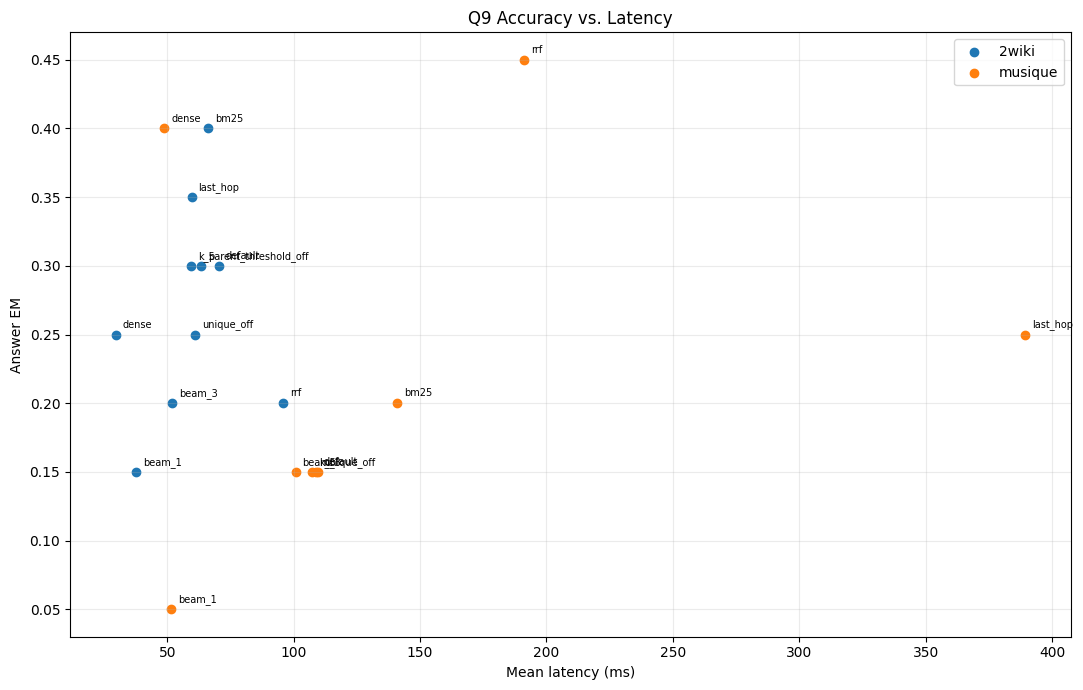

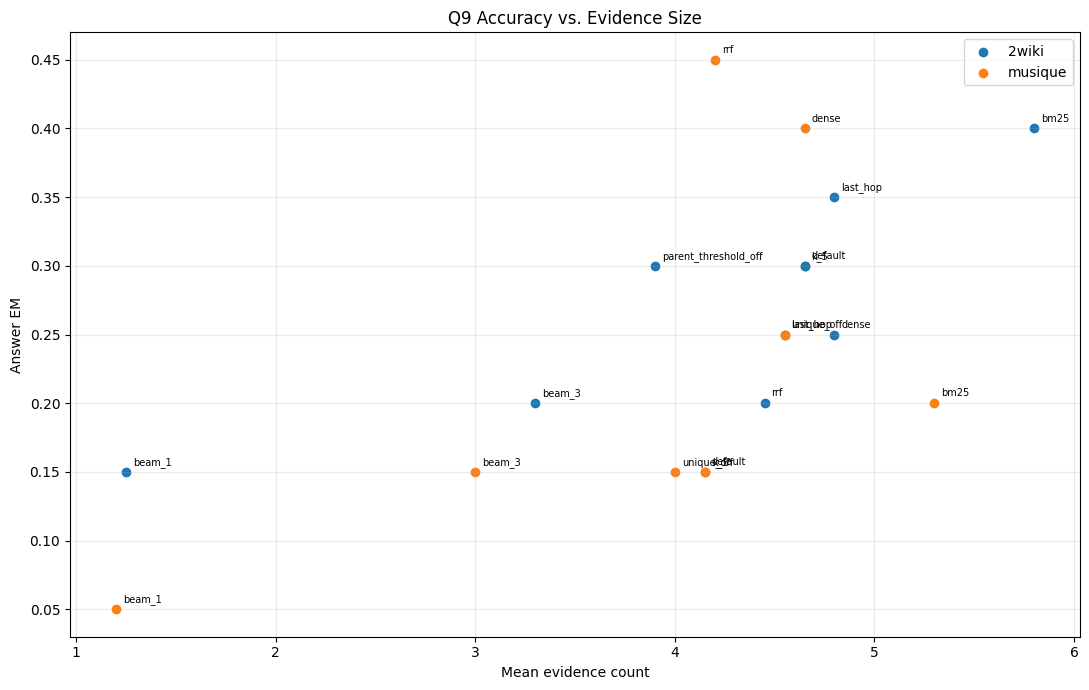

In [24]:
# Q9 — Overlayed trade-off plot: accuracy vs latency
import matplotlib.pyplot as plt

plot_df = q9_summary.dropna(
    subset=["EM", "mean_latency_ms"]
).copy()

plt.figure(figsize=(11, 7))

for dataset in DATASETS:
    group = plot_df[
        plot_df["dataset"] == dataset
    ]

    plt.scatter(
        group["mean_latency_ms"],
        group["EM"],
        label=dataset,
    )

    for _, row in group.iterrows():
        plt.annotate(
            row["configuration"],
            (
                row["mean_latency_ms"],
                row["EM"],
            ),
            fontsize=7,
            xytext=(5, 5),
            textcoords="offset points",
        )

plt.xlabel("Mean latency (ms)")
plt.ylabel("Answer EM")
plt.title("Q9 Accuracy vs. Latency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))

for dataset in DATASETS:
    group = plot_df[
        plot_df["dataset"] == dataset
    ]

    plt.scatter(
        group["mean_evidence_count"],
        group["EM"],
        label=dataset,
    )

    for _, row in group.iterrows():
        plt.annotate(
            row["configuration"],
            (
                row["mean_evidence_count"],
                row["EM"],
            ),
            fontsize=7,
            xytext=(5, 5),
            textcoords="offset points",
        )

plt.xlabel("Mean evidence count")
plt.ylabel("Answer EM")
plt.title("Q9 Accuracy vs. Evidence Size")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Your written response for Question 9

The ablation results suggest that dense retrieval is the best configuration to deploy overall. On 2Wiki, dense has the highest supporting-QA recall at 0.500 and is much faster than the default, with mean latency of 29.5 ms versus 70.5 ms. On MuSiQue, dense also performs strongly, reaching 0.479 recall, 0.35 complete-chain recovery, and the best EM and F1 at 0.40 and 0.512. RRF has slightly higher chain recovery on MuSiQue at 0.30, but its latency is much higher at 191.1 ms. This makes dense the better balance of accuracy and speed.

The beam results also show that keeping more alternatives helps. Moving from beam 1 to beam 3 improves recall and chain recovery on both datasets, although it increases latency and evidence size. Reducing k from 15 to 5 made almost no difference on this subset, suggesting the extra candidates were not especially useful here.

Because these experiments change one factor at a time, they cannot show how different choices work together. For example, a larger beam may help with one retrieval method but not another. The results therefore show which individual choices are useful, but not which combination is best overall.


## Stage C — Question 10: end-to-end 2Wiki evaluation (10 points)

Stage C reads saved RICR traces and loads only Qwen3-4B. The answer
model receives deduplicated QA evidence from every surviving final
beam, including role/state strings. It must not receive source
documents, graph neighbors, or gold labels. The supplied wrapper
already implements the required four-message one-shot PANINI prompt;
do not add an `N/A` instruction for these answerable splits.

In [25]:
from panini_course.metrics import exact_match, token_f1

def format_evidence(candidate):
    return (
        f"Q: {candidate.get('question', '')} "
        f"A: {', '.join(candidate.get('answer_names', []) or [])} "
        f"{' '.join(candidate.get('answer_role_states', []) or [])}"
    ).strip()

if RUN_ANSWER_STAGE:
    from panini_course.qwen_models import QwenAnswerer

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    answerer = QwenAnswerer(model_cfg['answer_model']['model'], quantized=True)
    try:
        for dataset, package in packages.items():
            traces = {row['question_id']: row for row in read_jsonl(
                WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl')
                if row.get('configuration') == 'default'}
            output = WORK_ROOT / 'cache' / dataset / 'answers.jsonl'
            done = completed_ids(output)
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done or qid not in traces:
                    continue
                trace = traces[qid]
                if trace.get('error'):
                    continue
                evidence_rows = trace['trace']['evidence']
                evidence = [format_evidence(row) for row in evidence_rows]
                started = time.perf_counter()
                generated = answerer.answer_with_trace(question['question'], evidence)
                promptText = answerer.tokenizer.apply_chat_template(
                    generated['messages'], tokenize=False,
                    add_generation_prompt=True, enable_thinking=False)
                record = {
                    'dataset': dataset,
                    'question_id': qid,
                    'question': question['question'],
                    'predicted_answer': generated['answer'],
                    'raw_answer_response': generated['response'],
                    'answer_evidence': evidence,
                    'answer_seconds': time.perf_counter() - started,
                    'answer_context_tokens': len(answerer.tokenizer(promptText)['input_ids']),
                }
                if 'answer' in question:
                    gold = [question['answer'], *question.get('answer_aliases', [])]
                    record['exact_match'] = exact_match(generated['answer'], gold)
                    record['token_f1'] = token_f1(generated['answer'], gold)
                append_jsonl(output, record)
                done.add(qid)
    finally:
        del answerer
        release_gpu()
else:
    print('Stage C disabled. Complete and checkpoint Stage B first.')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [26]:
def score_default_run(dataset, package):
    def load(name):
        return {str(r["question_id"]): r for r in read_jsonl(WORK_ROOT / "cache" / dataset / name)}

    decomps, answers = load("decompositions.jsonl"), load("answers.jsonl")
    traces = {str(r["question_id"]): r for r in read_jsonl(WORK_ROOT / "cache" / dataset / "ricr_traces.jsonl") if r.get("configuration") == 'default'}
    rows = []

    for q in package.questions("public"):
        qid = str(q["question_id"]); d, t, a = decomps.get(qid), traces.get(qid), answers.get(qid)
        tr = t.get("trace", {}) if t and not t.get("error") else {}
        ev = tr.get("evidence", []); ids = {str(x["qa_uid"]) for x in ev}; gold = q9_gold.get((dataset, qid), set())
        chains = tr.get("chains", []); chain_ids = [{str(x["qa_uid"]) for x in c.get("steps", [])} for c in chains]
        gold_docs = {str(catalog[dataset]["qa"][x]["document_id"]) for x in gold if x in catalog[dataset]["qa"]}
        evidence_docs = {str(x["document_id"]) for x in ev if x.get("document_id")}
        current = []
        for c in chains:
            vals = c.get("answers_by_step", {})
            if vals:
                last_key = max(vals, key=lambda x: int(x))
                value = vals[last_key]
                current.extend(value if isinstance(value, (list, tuple)) else [value])
        rows.append({
            "dataset": dataset,
            "question_id": qid,
            "question_type": q.get("type"),
            "hop_count": q.get("hop_count"),
            "decomposition_valid": bool(d and d.get("decomposition_valid")),
            "supporting_qa_recall": len(gold & ids) / len(gold) if gold else None,
            "supporting_document_recall": len(gold_docs & evidence_docs) / len(gold_docs) if gold_docs else None,
            "complete_chain_recovery": any(gold and gold <= s for s in chain_ids),
            "surviving_chains": len(chains),
            "unique_current_answers": len(set(map(str, current))),
            "evidence_count": len(ids),
            "EM": a.get("exact_match") if a else None,
            "F1": a.get("token_f1") if a else None,
            "answer_context_tokens": a.get("answer_context_tokens") if a else None,
            "retrieval_seconds": t.get("retrieval_seconds") if t else None,
            "answer_seconds": a.get("answer_seconds") if a else None,
        })

    df = pd.DataFrame(rows)
    df["total_latency_ms"] = df[["retrieval_seconds", "answer_seconds"]].fillna(0).sum(axis=1) * 1000
    return df

q10_scored = score_default_run("2wiki", packages["2wiki"])

q10_main = pd.DataFrame([{
    "dataset": "2wiki",
    "configuration": 'default',
    "questions": len(q10_scored),
    "decomposition_validity": q10_scored["decomposition_valid"].mean(),
    "supporting_document_recall": q10_scored["supporting_document_recall"].mean(),
    "supporting_qa_recall": q10_scored["supporting_qa_recall"].mean(),
    "complete_chain_recovery": q10_scored["complete_chain_recovery"].mean(),
    "average_surviving_chains": q10_scored["surviving_chains"].mean(),
    "average_unique_current_answers": q10_scored["unique_current_answers"].mean(),
    "EM": q10_scored["EM"].mean(),
    "F1": q10_scored["F1"].mean(),
    "mean_latency_ms": q10_scored["total_latency_ms"].mean(),
    "p95_latency_ms": q10_scored["total_latency_ms"].quantile(.95),
    "mean_answer_context_tokens": q10_scored["answer_context_tokens"].mean(),
    "mean_evidence_count": q10_scored["evidence_count"].mean(),
}])
display(q10_main)

q10_by_type = (
    q10_scored.groupby("question_type", dropna=False)
    .agg(questions=("question_id", "count"), EM=("EM", "mean"), F1=("F1", "mean"))
    .reset_index()
    .sort_values("question_type")
)
display(q10_by_type)

results_dir = WORK_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)
dev_path = results_dir / "2wiki_dev.jsonl"
with dev_path.open("w", encoding="utf-8") as f:
    for row in q10_scored.to_dict("records"):
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
print("Saved:", dev_path)

trace_index = {str(r["question_id"]): r for r in read_jsonl(WORK_ROOT / "cache" / "2wiki" / "ricr_traces.jsonl") if r.get("configuration") == 'default'}
success = q10_scored[(q10_scored["complete_chain_recovery"]) & (q10_scored["EM"] == 1.0)]
failure = q10_scored[q10_scored["EM"] == 0.0]

if not success.empty:
    sid = str(success.iloc[0]["question_id"])
    print("\nSUCCESS TRACE:", sid)
    print(json.dumps(trace_index[sid].get("trace", {}), indent=2, ensure_ascii=False)[:5000])

if not failure.empty:
    fid = str(failure.iloc[0]["question_id"])
    print("\nFAILED TRACE:", fid)
    print(json.dumps(trace_index[fid].get("trace", {}), indent=2, ensure_ascii=False)[:5000])

,dataset,configuration,questions,decomposition_validity,supporting_document_recall,supporting_qa_recall,complete_chain_recovery,average_surviving_chains,average_unique_current_answers,EM,F1,mean_latency_ms,p95_latency_ms,mean_answer_context_tokens,mean_evidence_count
0,2wiki,default,80,1.0,0.76875,0.59375,0.3125,4.4375,4.325,0.3875,0.420536,9286.945951,22789.73977,538.5,5.175


,question_type,questions,EM,F1
0,bridge_comparison,20,0.35,0.358333
1,comparison,20,0.55,0.603571
2,compositional,20,0.50,0.500000
3,inference,20,0.15,0.220238


Saved: /content/drive/MyDrive/panini-course-project-work/results/2wiki_dev.jsonl

SUCCESS TRACE: d5cec92708df11ebbda1ac1f6bf848b6
{
  "components": [
    [
      1,
      2,
      3
    ]
  ],
  "chains": [
    {
      "steps": [
        {
          "qa_uid": "doc_3485::gsw_3485_0.json::v2::q4",
          "answer_names": [
            "5 August 1879"
          ],
          "score": 0.578125,
          "question": "When did Charles Albert Fechter die?",
          "answer_ids": [
            "doc_3485::gsw_3485_0.json::e3"
          ],
          "answer_role_states": [
            "date: death date, 19th century"
          ],
          "document_id": "doc_3485",
          "metadata": {
            "gsw_file": "gsw_3485_0.json",
            "verb_phrase_id": "v2",
            "routes": [
              "entity_bm25_expand",
              "qa_dense"
            ],
            "route_ranks": {
              "qa_dense": 1,
              "entity_bm25_expand": 4
            },
            "pre_

### Your written response for Question 10

The 2Wiki results show that most failures happened after decomposition. All 80 plans were valid, but supporting-QA recall was only 0.59375 and complete-chain recovery fell to 0.3125, showing that finding individual facts was easier than preserving the full chain.

The failed trace for `5cbb015f087511ebbd67ac1f6bf848b6` shows a later-hop retrieval failure. The first two hops correctly found `Maxwell Shane` and `Rod Amateau`, but the next step retrieved `“Who is American?”` instead of `Maxwell Shane`’s date of death. This was the first irreversible error because the later comparison needed the correct death dates, so later stages could not recover.

Overall EM was 0.3875 and F1 was 0.4205, while chain recovery was lower at 0.3125. This demonstrates that a correct final answer does not imply the full evidence chain was recovered. By question type, comparison performed best at 0.55 EM, while inference was lowest at 0.15. The main bottleneck was therefore later-hop retrieval and substitution rather than decomposition.


## Question 11 — MuSiQue transfer and scaling (12 points)

Freeze all 2Wiki choices before inspecting MuSiQue results. Use the
same decomposition prompt, retrieval settings, beam rules,
reranker, answer prompt, and metrics. Compare 2-, 3-, and 4-hop
questions without tuning on MuSiQue labels.

,hop_count,questions,decomposition_validity,supporting_document_recall,supporting_qa_recall,complete_chain_recovery,average_surviving_chains,average_unique_current_answers,EM,F1,mean_latency_ms,p95_latency_ms,mean_answer_context_tokens,mean_evidence_count
0,2,40,1.0,0.687500,0.425000,0.200000,4.375000,3.875000,0.30,0.326786,24337.082566,39725.139918,511.400000,4.800000
1,3,24,1.0,0.583333,0.361111,0.041667,4.791667,3.666667,0.25,0.250000,41810.753339,59521.065762,536.791667,4.958333
2,4,16,1.0,0.421875,0.281250,0.000000,3.750000,3.375000,0.00,0.035714,49036.600957,80583.019135,512.437500,4.187500


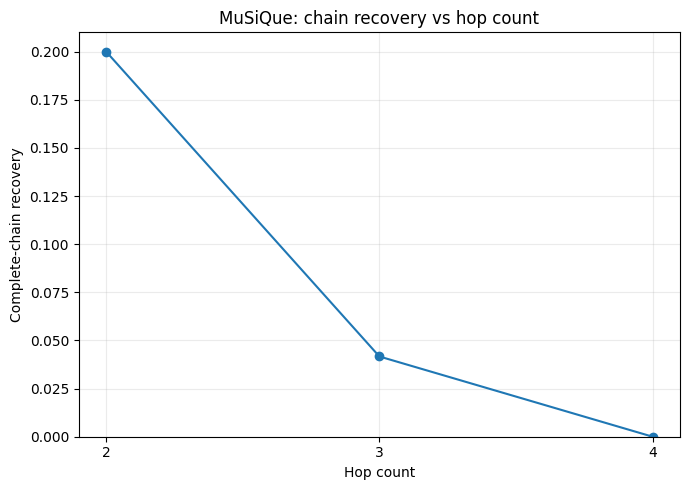

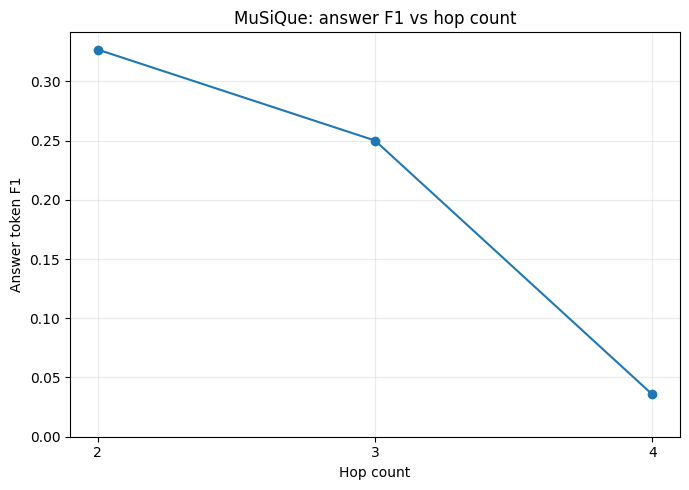

,dataset,questions,supporting_qa_recall,complete_chain_recovery,EM,F1
0,2wiki,80,0.593750,0.3125,0.3875,0.420536
1,musique,80,0.377083,0.1125,0.2250,0.245536


,dataset,decomposition,first_hop_retrieval,later_hop_retrieval,answer_generation
0,2wiki,0,17,25,7
1,musique,0,26,34,2


In [27]:
# Q11 — MuSiQue scaling, cross-dataset comparison, and traced error attribution

musique_scored = score_default_run("musique", packages["musique"])

if musique_scored.empty:
    print("No MuSiQue results found. Complete Stage B and Stage C first.")
else:
    musique_by_hop = (musique_scored.groupby("hop_count")
        .agg(questions=("question_id","count"),
             decomposition_validity=("decomposition_valid","mean"),
             supporting_document_recall=("supporting_document_recall","mean"),
             supporting_qa_recall=("supporting_qa_recall","mean"),
             complete_chain_recovery=("complete_chain_recovery","mean"),
             average_surviving_chains=("surviving_chains","mean"),
             average_unique_current_answers=("unique_current_answers","mean"),
             EM=("EM","mean"), F1=("F1","mean"),
             mean_latency_ms=("total_latency_ms","mean"),
             p95_latency_ms=("total_latency_ms",lambda x:x.quantile(.95)),
             mean_answer_context_tokens=("answer_context_tokens","mean"),
             mean_evidence_count=("evidence_count","mean"))
        .reset_index().sort_values("hop_count"))
    display(musique_by_hop)

    for metric,title,ylabel in [
        ("complete_chain_recovery","MuSiQue: chain recovery vs hop count","Complete-chain recovery"),
        ("F1","MuSiQue: answer F1 vs hop count","Answer token F1")]:
        plt.figure(figsize=(7,5))
        plt.plot(musique_by_hop["hop_count"],musique_by_hop[metric],marker="o")
        plt.xlabel("Hop count"); plt.ylabel(ylabel); plt.title(title)
        plt.xticks(musique_by_hop["hop_count"]); plt.ylim(0,)
        plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    twowiki_scored = score_default_run("2wiki", packages["2wiki"])
    cross_dataset = pd.DataFrame([
        {"dataset":"2wiki","questions":len(twowiki_scored),
         "supporting_qa_recall":twowiki_scored["supporting_qa_recall"].mean(),
         "complete_chain_recovery":twowiki_scored["complete_chain_recovery"].mean(),
         "EM":twowiki_scored["EM"].mean(),"F1":twowiki_scored["F1"].mean()},
        {"dataset":"musique","questions":len(musique_scored),
         "supporting_qa_recall":musique_scored["supporting_qa_recall"].mean(),
         "complete_chain_recovery":musique_scored["complete_chain_recovery"].mean(),
         "EM":musique_scored["EM"].mean(),"F1":musique_scored["F1"].mean()}
    ])
    display(cross_dataset)

gold_by_step = {}
for task in atomic_tasks:
    key = (task["dataset"], str(task["outer_question_id"]), int(task["step"]))
    gold_by_step.setdefault(key, set()).update(map(str, task.get("relevant_qa_ids", [])))

def attribute_errors(dataset, scored):
    trace_map = {str(r["question_id"]): r for r in read_jsonl(
        WORK_ROOT / "cache" / dataset / "ricr_traces.jsonl")
        if r.get("configuration") == 'default'}
    failures = {
        "decomposition": 0,
        "first_hop_retrieval": 0,
        "later_hop_retrieval": 0,
        "answer_generation": 0,
    }

    for _, row in scored.iterrows():
        if row["EM"] != 0.0:
            continue

        qid = str(row["question_id"])

        if not row["decomposition_valid"]:
            failures["decomposition"] += 1
            continue

        trace = trace_map.get(qid, {}).get("trace", {})
        evidence = {str(x["qa_uid"]) for x in trace.get("evidence", [])}

        steps = sorted(
            step for ds, q, step in gold_by_step
            if ds == dataset and q == qid
        )
        first_gold = gold_by_step.get(
            (dataset, qid, steps[0]), set()
        ) if steps else set()
        later_gold = set().union(
            *(gold_by_step.get((dataset, qid, step), set())
              for step in steps[1:])
        ) if len(steps) > 1 else set()

        if first_gold and not first_gold.issubset(evidence):
            failures["first_hop_retrieval"] += 1
        elif later_gold and not later_gold.issubset(evidence):
            failures["later_hop_retrieval"] += 1
        else:
            failures["answer_generation"] += 1

    return failures

q10_failures = attribute_errors("2wiki", twowiki_scored)
q11_failures = attribute_errors("musique", musique_scored)

transfer_error_table = pd.DataFrame([
    {"dataset": "2wiki", **q10_failures},
    {"dataset": "musique", **q11_failures},
])

display(transfer_error_table)

### Your written response for Question 11

Complete-chain recovery is conjunctive because every required hop must succeed. As hop count increases from 2 to 4, recovery drops from 0.20 to 0.00, while answer F1 also falls from 0.327 to 0.036. The larger drop in chain recovery is expected because each additional hop introduces another opportunity for retrieval, substitution, or pruning to fail. One incorrect hop is enough to break the complete chain, even when the final answer may still receive partial F1 credit.

Hop count alone does not explain the difference between 2Wiki and MuSiQue, however. The datasets also differ in wording, entity distribution, and GSW coverage.

The results therefore show that longer chains increase structural failure risk, but dataset-specific retrieval conditions also matter. The 2-hop questions achieved the highest supporting-QA recall at 0.425, compared with 0.361 for 3-hop and 0.281 for 4-hop, evidence that additional hops make evidence recovery harder. Answer F1 follows the same general trend, but it is less strict than complete-chain recovery because partial or independently correct answers can still receive credit.


## Question 12 — reproducibility and final submission (12 points)

Materialize exactly four submission files: 80 labeled development
results and 20 label-free held-out predictions for each dataset.
Verify counts by stable question ID, not just line count. Record the
environment, frozen configuration, model IDs, resume instructions,
and which timings were cold versus cache replay.

In [28]:
import json, math, platform, subprocess, sys
from pathlib import Path

SUBMISSION_ROOT = WORK_ROOT / "submission"
SUBMISSION_ROOT.mkdir(parents=True, exist_ok=True)

required_files = {
    SUBMISSION_ROOT/"results/2wiki_dev.jsonl": 80,
    SUBMISSION_ROOT/"predictions/2wiki_heldout.jsonl": 20,
    SUBMISSION_ROOT/"results/musique_dev.jsonl": 80,
    SUBMISSION_ROOT/"predictions/musique_heldout.jsonl": 20,
}

def materialize_submission(dataset, package):
    answers = {str(r["question_id"]): r for r in read_jsonl(WORK_ROOT/"cache"/dataset/"answers.jsonl")}
    public = {str(q["question_id"]) for q in package.questions("public")}
    heldout = {str(q["question_id"]) for q in package.questions("held_out")}
    out_dev = SUBMISSION_ROOT/"results"/f"{dataset}_dev.jsonl"
    out_hold = SUBMISSION_ROOT/"predictions"/f"{dataset}_heldout.jsonl"
    out_dev.parent.mkdir(parents=True, exist_ok=True)
    out_hold.parent.mkdir(parents=True, exist_ok=True)

    dev_rows = []
    for qid in sorted(public):
        if qid not in answers: continue
        r = dict(answers[qid])
        r["question_id"] = qid
        dev_rows.append(r)

    hold_rows = []
    allowed = {"dataset","question_id","question","predicted_answer","raw_answer_response",
               "answer_evidence","answer_seconds","answer_context_tokens","retrieval_seconds"}
    for qid in sorted(heldout):
        if qid not in answers: continue
        hold_rows.append({k:v for k,v in answers[qid].items() if k in allowed})

    for path, rows in [(out_dev,dev_rows),(out_hold,hold_rows)]:
        path.write_text(
            "\n".join(json.dumps(r,ensure_ascii=False) for r in rows)+"\n",
            encoding="utf-8"
        )
    return out_dev, out_hold

def validate_submission_file(path, expected, allowed_heldout_fields=None):
    rows = read_jsonl(path)
    ids = [str(r.get("question_id","")) for r in rows]
    assert len(rows) == expected, f"{path}: expected {expected}, got {len(rows)}"
    assert all(ids), f"{path}: missing question_id"
    assert len(set(ids)) == expected, f"{path}: duplicate question IDs"
    for r in rows:
        for key, value in r.items():
            if isinstance(value,float): assert math.isfinite(value), f"{path}: non-finite {key}"
    if allowed_heldout_fields is not None:
        extra = set().union(*(set(r)-allowed_heldout_fields for r in rows))
        assert not extra, f"{path}: forbidden held-out fields {sorted(extra)}"
    return ids

if QUESTION_LIMIT is None and all(path.exists() for path in required_files):
    for path, expected in required_files.items():
        validate_submission_file(path, expected)
    print("All required submission files validated.")
else:
    print("Final validation waits until QUESTION_LIMIT=None and all files exist.")

All required submission files validated.


In [29]:
# TODO Q12: write environment.txt and RUNME.md. Include at least:
environment = {
    'python': sys.version,
    'platform': platform.platform(),
    'question_limit': QUESTION_LIMIT,
    'beam_width': BEAM_WIDTH,
    'candidates_per_hop': CANDIDATES_PER_HOP,
    'retrieval_pool': RETRIEVAL_POOL,
    'rrf_constant': RRF_CONSTANT,
    'multi_parent_threshold': MULTI_PARENT_THRESHOLD,
    'package_manifests': {
        name: package.manifest for name, package in packages.items()
    },
}
(WORK_ROOT/'environment.json').write_text(
    json.dumps(environment, indent=2, ensure_ascii=False), encoding='utf-8')
print('environment:', WORK_ROOT/'environment.json')

environment: /content/drive/MyDrive/panini-course-project-work/environment.json


### Your written response for Question 12

Let' use the question “Which film director died later, Film A or Film B?” The system first sends the question to the decomposition model in Stage A, which breaks it into retrieval steps: find Film A’s director, find Film B’s director, and then compare their death dates. Because the last step depends on both earlier answers, the steps are stored as a retrieval DAG rather than treated as independent questions.

In Stage B, each question is searched against the stored QA records using the retrieval and reranking pipeline. RICR then keeps multiple candidate chains instead of committing to a single answer. One important design choice is the RICR converging comparison step. It forms combinations of the parent beams and scores them with a harmonic mean, so a weak parent lowers the score of the whole combination. This preserves several plausible answer assignments while preventing one strong branch from masking a weak one entirely. The selected parent answers are then substituted into the comparison question before the next retrieval.

However, this process can still fail at a later hop. In one trace, the system correctly retrieved “5 August 1879” for Charles Albert Fechter’s death and Baron Félix de Blochausen for the second branch. However, the next retrieval returned an unrelated QA record, “Who is American?”, with Maxwell Shane as the answer. That incorrect candidate became part of the chain state, so later stages could not recover the intended comparison.

After RICR finishes, evidence from all surviving final beams is deduplicated and passed to Stage C, where the answer model generates the final response from the retrieved evidence. The gold answer is never provided to the answer model.

 All intermediate results are saved as JSONL, including decompositions, RICR traces, ablation results, and answers. In order to reproduce these results, a student can clone the repository and run this colab notebook. In order to save time, a A100 GPU was used (effectively 400%+ faster). However, the notebook is implemented in a way that a T4 GPU can yield the same results and may be resumed in the event that the runtime expires.


## Final pre-submission checklist

- [ ] `QUESTION_LIMIT` was set to `None` for final runs.
- [ ] All supplied tests pass, plus your reconciliation and failure-case tests.
- [ ] Every expensive stage resumes from JSONL by stable question ID.
- [ ] Only one Qwen model was resident at a time.
- [ ] No embeddings were generated.
- [ ] The 2Wiki configuration was frozen before MuSiQue evaluation.
- [ ] All twelve written-response cells were replaced with your own analysis.
- [ ] Held-out outputs contain no answer, alias, or supporting-evidence labels.
- [ ] Four required JSONL files, the executed notebook, figures, tests,
  `environment.json`, and `RUNME.md` are included.

In [37]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Project3 261A Jadon Nguyen"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Project3 261A Jadon Nguyen to pdf
[NbConvertApp] Support files will be in Project3 261A Jadon Nguye_files/
[NbConvertApp] Making directory ./Project3 261A Jadon Nguye_files
[NbConvertApp] Writing 618979 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 778882 bytes to /content/drive/MyDrive/Colab Notebooks/Project3 261A Jadon Nguye.pdf
